# **Miniproyecto**

## **Importar Librerías**

Se importan las librerías esenciales para facilitar el análisis que abarca la carga de datos, la visualización, la transformación de datos, la fusión y la unión.

In [1]:
import warnings
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
from scipy.stats.mstats import winsorize
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import kruskal
from scipy.stats import spearmanr
from scipy.stats import f_oneway
from scipy.stats import ttest_ind
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from imblearn.over_sampling import SMOTE
from scipy.stats import kurtosis
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.naive_bayes import GaussianNB, BernoulliNB, MultinomialNB
from sklearn.metrics import classification_report
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.linear_model import LogisticRegressionCV
from sklearn.calibration import calibration_curve
warnings.filterwarnings("ignore")

## **Lectura de Datos**

Se Importa la función `fetch_ucirepo` del paquete `ucimlrepo`.  
`fetch_ucirepo` es la función clave para descargar datasets usando su ID único.

In [2]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
heart_disease = fetch_ucirepo(id=45) 
  
# data (as pandas dataframes) 
X = heart_disease.data.features 
y = heart_disease.data.targets 
  
# metadata 
heart_disease.metadata 
  
# Se unen X e y (ambos son DataFrames) con el fin de facilitar el EDA
df = pd.concat([X, y], axis=1)

Se muestran las primeras filas del DataFrame.  

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


Se muestran las últimas filas del DataFrame.  

In [4]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
298,45,1,1,110,264,0,0,132,0,1.2,2,0.0,7.0,1
299,68,1,4,144,193,1,0,141,0,3.4,2,2.0,7.0,2
300,57,1,4,130,131,0,0,115,1,1.2,2,1.0,7.0,3
301,57,0,2,130,236,0,2,174,0,0.0,2,1.0,3.0,1
302,38,1,3,138,175,0,0,173,0,0.0,1,NaN,3.0,0


Se emplea el método `df.info()` para evaluar la estructura y calidad inicial del dataset. Este análisis revela información sobre la composición de los datos, incluyendo el número total de registros (filas) y variables (columnas), los tipos de datos asociados a cada campo (como objetos, enteros o valores flotantes), y la cantidad de valores no nulos por columna.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


**Interpretación**

El análisis inicial de la estructura del dataset revela lo siguiente:

1.  **Volumen de Datos:** El conjunto de datos está compuesto por 303 observaciones o pacientes (entradas) y 14 atributos o variables (columnas) para cada uno.

2.  **Completitud de los Datos:**
    *   La mayoría de las columnas (`age`, `sex`, `cp`, `trestbps`, `chol`, `fbs`, `restecg`, `thalach`, `exang`, `oldpeak`, `slope`, `num`) presentan 303 valores no nulos, lo que indica que están completas para todos los pacientes.
    *   Se detectaron valores faltantes en dos variables específicas:
        *   `ca` (número de vasos principales coloreados por fluoroscopia): 4 valores faltantes (303 - 299).
        *   `thal` (talasemia): 2 valores faltantes (303 - 301).

3.  **Tipos de Datos:**
    *   El dataset contiene una mezcla de variables numéricas enteras (`int64`), numéricas decimales (`float64`) y, por la naturaleza de los datos, varias variables categóricas codificadas como enteros (p. ej., `sex`, `cp`, `fbs`, `exang`).
    *   **Variables Categóricas Codificadas:** `sex` (género), `cp` (tipo de dolor torácico), `fbs` (azúcar en ayunas), `restecg` (electrocardiograma en reposo), `exang` (angina inducida), `slope` (pendiente del ST), `thal` (talasemia) y la variable objetivo `num` (diagnóstico) deben ser interpretadas como categóricas a pesar de su tipo numérico. Esta codificación es estándar para su procesamiento algorítmico.
    *   **Variables Numéricas:** `age` (edad), `trestbps` (presión arterial), `chol` (colesterol), `thalach` (frecuencia cardíaca máxima) y `oldpeak` (depresión del ST) son verdaderamente numéricas.

4.  **Variable Objetivo (`num`):** La columna `num` representa el diagnóstico de enfermedad cardíaca y está completa (303 non-null). Según la descripción del dataset de UCI, los valores van de 0 (no presencia) a 4 (enfermedad en diferentes grados). **Para un análisis de clasificación binaria, es común reagrupar los valores >0 en una sola clase (1 = presencia de enfermedad)**.

5.  **Consumo de Memoria:** La estructura de datos consume aproximadamente 33.3 KB de memoria, lo que confirma que es un conjunto de datos de tamaño manejable que no requiere técnicas especiales de optimización de memoria.

### **Valores únicos**

Se calcula el número de valores únicos para cada variable del DataFrame.

In [6]:
df.nunique()

age          41
sex           2
cp            4
trestbps     50
chol        152
fbs           2
restecg       3
thalach      91
exang         2
oldpeak      40
slope         3
ca            4
thal          3
num           5
dtype: int64

**Interpretación**

El número de valores únicos para cada variable permite clasificarlas de manera precisa y definir la estrategia de preprocesamiento para el modelado predictivo.

- **Variables Numéricas:** Se identificaron cinco variables con una alta cantidad de valores únicos, lo que indica su naturaleza. Estas son la edad del paciente, la presión arterial en reposo, el nivel de colesterol sérico, la frecuencia cardíaca máxima alcanzada y la depresión del segmento ST inducida por el ejercicio. **Esta característica es crucial, ya que indica que deben ser escaladas para que los algoritmos de machine learning interpreten su importancia de manera equitativa**.

- **Variables Categóricas:** La mayoría de las variables restantes presentan una cardinalidad baja, confirmando su naturaleza categórica. Esto incluye el sexo del paciente, el tipo de dolor torácico, el resultado del electrocardiograma en reposo y la presencia de angina inducida por ejercicio, las cuales son binarias o tienen pocas categorías. Dos variables categóricas críticas, que representan el número de vasos principales visibles en fluoroscopia y un diagnóstico de talasemia, mostraron una cantidad limitada de valores posibles. **Este hallazgo corrobora que la estrategia adecuada para manejar sus valores faltantes es la imputación utilizando el valor más frecuente (moda) y no medidas de tendencia central como la media**.

- **Variable Objetivo:** El análisis de la variable de diagnóstico confirma que contiene cinco categorías distintas, correspondientes a la ausencia de enfermedad y cuatro niveles de severidad de la misma. **Esto valida el enfoque estándar de agrupar las categorías de enfermedad en una sola clase positiva para transformar el problema en una clasificación binaria, que es más manejable y común en la literatura para este conjunto de datos**.

En conclusión, este análisis sienta las bases técnicas para un preprocesamiento de datos riguroso, asegurando que cada variable sea tratada de acuerdo con su naturaleza estadística para optimizar el rendimiento de los modelos predictivos subsiguientes.

### **Valores Nulos**

Para cuantificar la magnitud de datos ausentes en cada columna, se calculó el porcentaje de valores nulos mediante `df.isnull().mean() * 100`. Este indicador permite identificar variables críticas que requieren intervención prioritaria en el proceso de limpieza.

In [7]:
df.isnull().mean() * 100

age         0.000000
sex         0.000000
cp          0.000000
trestbps    0.000000
chol        0.000000
fbs         0.000000
restecg     0.000000
thalach     0.000000
exang       0.000000
oldpeak     0.000000
slope       0.000000
ca          1.320132
thal        0.660066
num         0.000000
dtype: float64

**Interpretación**

El análisis de valores nulos revela que la mayoría de las variables (`age`, `sex`, `cp`, `trestbps`, `chol`, `fbs`, `restecg`, `thalach`, `exang`, `oldpeak`, `slope`, `num`) presentan una integridad del **100%**, lo que indica un dataset muy completo para estos atributos. Sin embargo, se identificaron dos variables con valores faltantes: la variable `ca` (número de vasos principales coloreados por fluoroscopia) presenta un **1.32%** de datos nulos, y la variable `thal` (talasemia, un defecto sanguíneo) presenta un **0.66%**. Aunque el porcentaje de valores faltantes es marginal, estas variables son clínicamente significativas para la predicción de cardiopatías, por lo que se requiere una estrategia de imputación adecuada para preservar la integridad del dataset y no perder instancias valiosas.

## **Imputación de Valores Nulos**

Para manejar los valores faltantes previamente identificados en las variables `ca` (número de vasos principales) y `thal` (talasemia), se procedió con una estrategia de imputación. Dado que ambas son variables categóricas ordinales y nominales, respectivamente, la medida de tendencia central más apropiada para preservar la distribución de los datos es la **moda** (el valor más frecuente). Este enfoque evita la introducción de valores decimales artificiales que una imputación por media generaría, manteniendo la integridad de las categorías originales y siendo una técnica robusta.

Se analizan los valores únicos presentes en la variable objetivo `ca` para conocer las categorías de diagnóstico originales antes de cualquier transformación.

In [8]:
df["ca"].unique()

array([ 0.,  3.,  2.,  1., nan])

Se analizan los valores únicos presentes en la variable objetivo `thal` para conocer las categorías de diagnóstico originales antes de cualquier transformación.

In [9]:
df["thal"].unique()

array([ 6.,  3.,  7., nan])

Se aplica el método `value_counts()` para hallar la moda en la variable `ca`.

In [10]:
df["ca"].value_counts()

ca
0.0    176
1.0     65
2.0     38
3.0     20
Name: count, dtype: int64

Se aplica el método `value_counts()` para hallar la moda en la variable `thal`.

In [11]:
df["thal"].value_counts()

thal
3.0    166
7.0    117
6.0     18
Name: count, dtype: int64

Para abordar la presencia marginal de valores nulos en las variables `ca` y `thal`, y con el objetivo de preservar la totalidad de los registros para el análisis, se procedió a una imputación simple utilizando la moda de cada variable. Esta estrategia asegura la consistencia en la distribución de los datos al reemplazar los valores faltantes por la categoría más frecuente, minimizando el impacto potencial en el posterior entrenamiento de los modelos.

In [12]:
df["ca"] = df["ca"].fillna(0.0)
df["thal"] = df["thal"].fillna(3.0)

Se verifican los cambios realizados.

In [13]:
df.isnull().mean() * 100

age         0.0
sex         0.0
cp          0.0
trestbps    0.0
chol        0.0
fbs         0.0
restecg     0.0
thalach     0.0
exang       0.0
oldpeak     0.0
slope       0.0
ca          0.0
thal        0.0
num         0.0
dtype: float64

## **Conversión de Variable Objetivo (Categórica -> Binaria)**

Se analizan los valores únicos presentes en la variable objetivo `num` para conocer las categorías de diagnóstico originales antes de cualquier transformación.

In [14]:
df["num"].unique()

array([0, 2, 1, 3, 4])

Con el fin de simplificar el problema a una tarea de clasificación binaria (presencia vs. ausencia de enfermedad), los valores originales de diagnóstico que indicaban distintos grados de severidad **(2, 3 y 4)** fueron reagrupados en la categoría única **(1)**, que representa la presencia de enfermedad cardíaca.

In [15]:
df["num"].replace(to_replace=[2,3,4], value=[1,1,1] , inplace=True)

Se verifican los cambios realizados.

In [16]:
df["num"].unique()

array([0, 1])

## **Análisis Univariado**

El Análisis Univariado es la primera fase del análisis exploratorio de datos. Se enfoca en el estudio individual de cada variable para entender su distribución, características y valores atípicos. Esto permite identificar patrones y la calidad de los datos antes de un análisis más complejo.

### **Variables Binarias**

Se identifican y analizan las variables binarias (aquellas con solo 2 valores únicos) en el DataFrame.  

**Mostrando**: 

1. Conteo absoluto de ocurrencias para cada valor (0 y 1).  

2. Porcentaje respecto al total (redondeado a 1 decimal).

In [17]:
binarias = [col for col in df.columns if df[col].nunique() == 2]


data = {
    col: [
        f"{df[col].value_counts().get(0, 0)} ({round(df[col].value_counts(normalize=True).get(0, 0)*100, 1)}%)",  
        f"{df[col].value_counts().get(1, 0)} ({round(df[col].value_counts(normalize=True).get(1, 0)*100, 1)}%)" 
    ] for col in binarias
}

tabla_porcentajes = pd.DataFrame(data, index=['(0)', '(1)'])

display(tabla_porcentajes)  

,sex,fbs,exang,num
(0),97 (32.0%),258 (85.1%),204 (67.3%),164 (54.1%)
(1),206 (68.0%),45 (14.9%),99 (32.7%),139 (45.9%)


Luego, se genera un doble gráfico para cada variable binaria, permitiendo comparar su distribución mediante:

1. **Gráfico de Barras**:  
    - Muestra el conteo absoluto de cada categoría (0 y 1).  
    - Ideal para comparar magnitudes visualmente.
    
2. **Gráfico de Torta**:  
    - Muestra la proporción porcentual de cada categoría.  
    - Útil para entender el balance/imbalance entre clases.


=== SEX ===


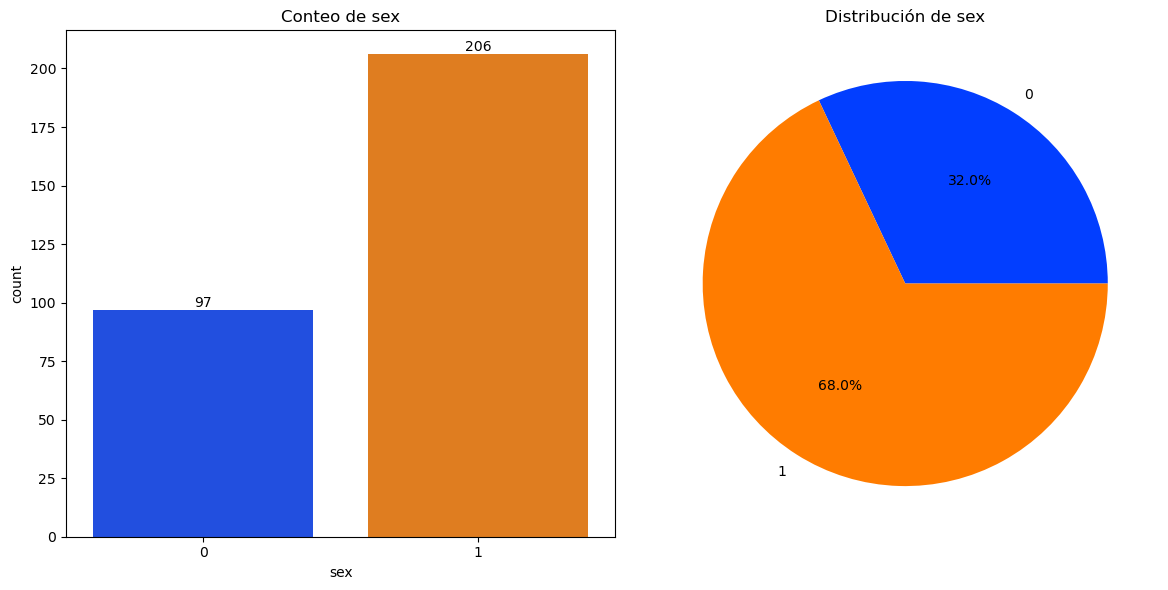


=== FBS ===


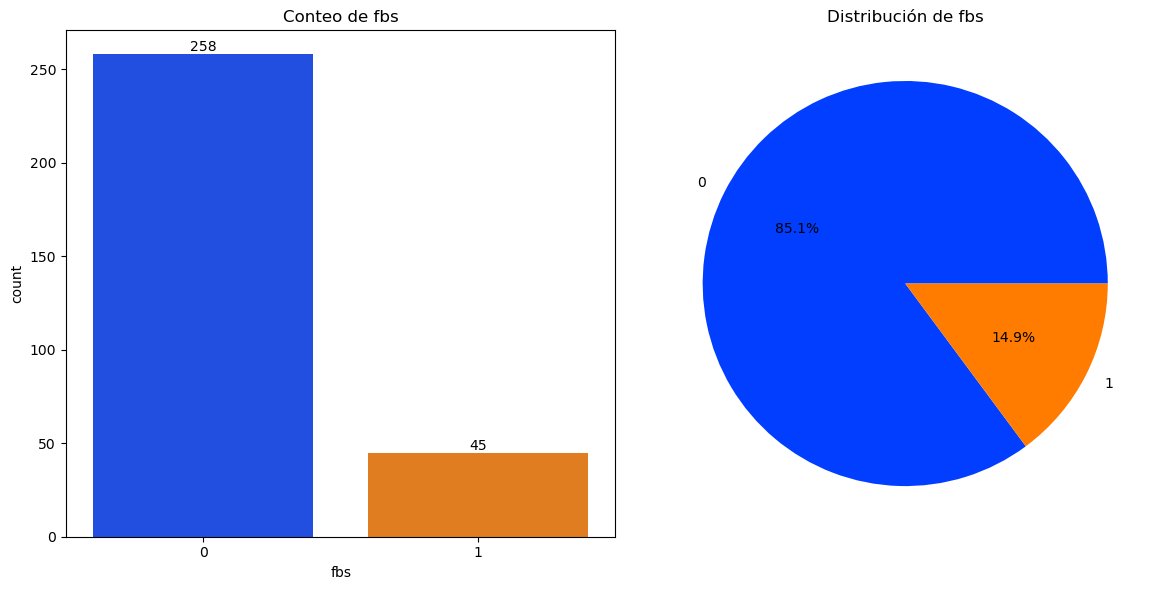


=== EXANG ===


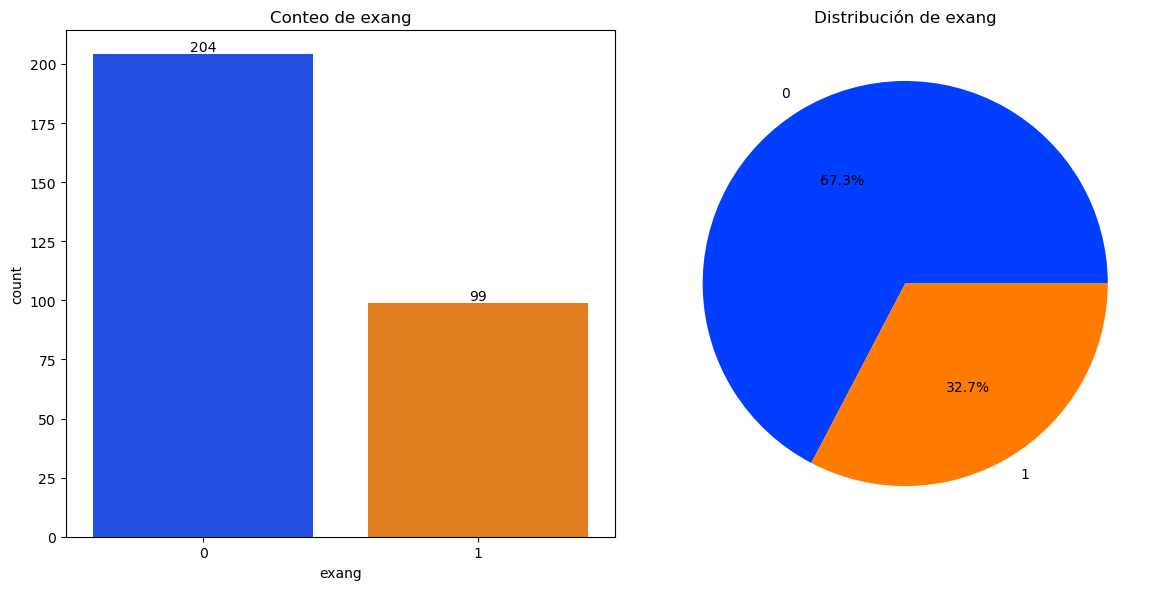


=== NUM ===


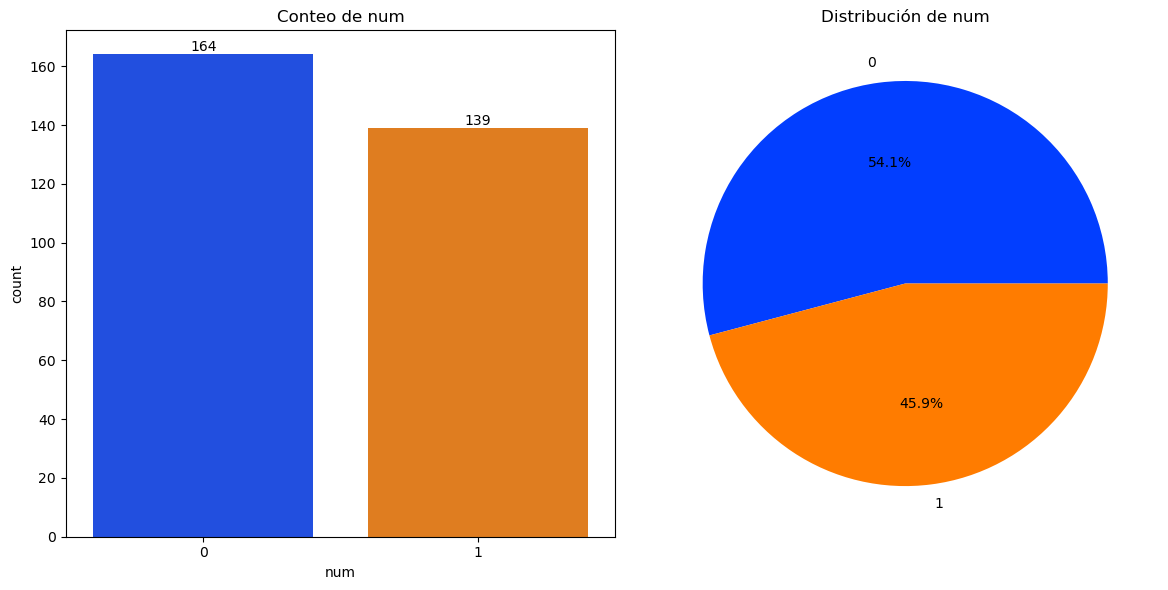

In [18]:
for col in binarias:
    
    print(f"\n=== {col.upper()} ===")
    plt.figure(figsize=(12, 6))
    
    # Definir el orden y los colores consistentes
    value_order = sorted(df[col].unique())
    colors = sns.color_palette('bright')  # Misma paleta para ambos gráficos
    
    # Primer subplot - Gráfico de barras
    plt.subplot(1, 2, 1)
    ax = sns.countplot(x=df[col], palette=colors, order=value_order)
    plt.title(f'Conteo de {col}')
    
    # Añadir los valores encima de las barras
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', label_type='edge', padding=0)
    
    # Segundo subplot - Diagrama de torta
    plt.subplot(1, 2, 2)
    counts = df[col].value_counts().loc[value_order]  # Ordenar los conteos
    plt.pie(counts, 
            labels=counts.index, 
            autopct='%1.1f%%',
            colors=colors)  # Usar la misma paleta ordenada
    plt.title(f'Distribución de {col}')
    
    plt.tight_layout()
    plt.show()

**Interpretación**

1. `sex`: La mayoría de los pacientes en el dataset son hombres (código 1), representando aproximadamente dos tercios de la muestra. Esta distribución sugiere un posible desbalance de género, lo que podría influir en los modelos predictivos si el género está correlacionado con la enfermedad.

2. `fbs` (Nivel de azúcar en sangre en ayunas > 120 mg/dl): Solo una minoría de pacientes presenta niveles elevados de azúcar en sangre en ayunas. Esto indica que la hiperglucemia en ayunas no es común en esta población, pero su presencia podría ser un predictor relevante para la enfermedad cardíaca debido a su rareza.

3. `exang` (Angina inducida por ejercicio): Aproximadamente un tercio de los pacientes experimenta angina desencadenada por el ejercicio. Esta variable es clínicamente significativa, ya que la angina inducida por esfuerzo es un síntoma clásico de enfermedad arterial coronaria.

4. `num` (Variable objetivo - Diagnóstico de enfermedad cardíaca): Existe un equilibrio casi perfecto entre las clases de la variable objetivo. Esto es ideal para el entrenamiento de modelos de machine learning, ya que evita problemas de desbalance que podrían sesgar las predicciones.

- Las variables binarias presentan distribuciones heterogéneas: algunas están balanceadas (`num`), mientras que otras muestran predominancia de una categoría (`sex`, `fbs`, `exang`).
- El desbalance en variables predictoras (ej: `fbs`) no necesariamente es un problema, pero deberá monitorearse su impacto en el modelo.
- La distribución de la variable objetivo (`num`) es balanceada, lo que facilita el entrenamiento de modelos predictivos.

### **Variables Categóricas**

Se generan gráficos de barras para visualizar la distribución de cada variable categórica. 

**Cada gráfico muestra**:

- El número absoluto de observaciones (conteo).
- El porcentaje relativo respecto al total.
- Las categorías ordenadas según su escala natural.


=== CP ===


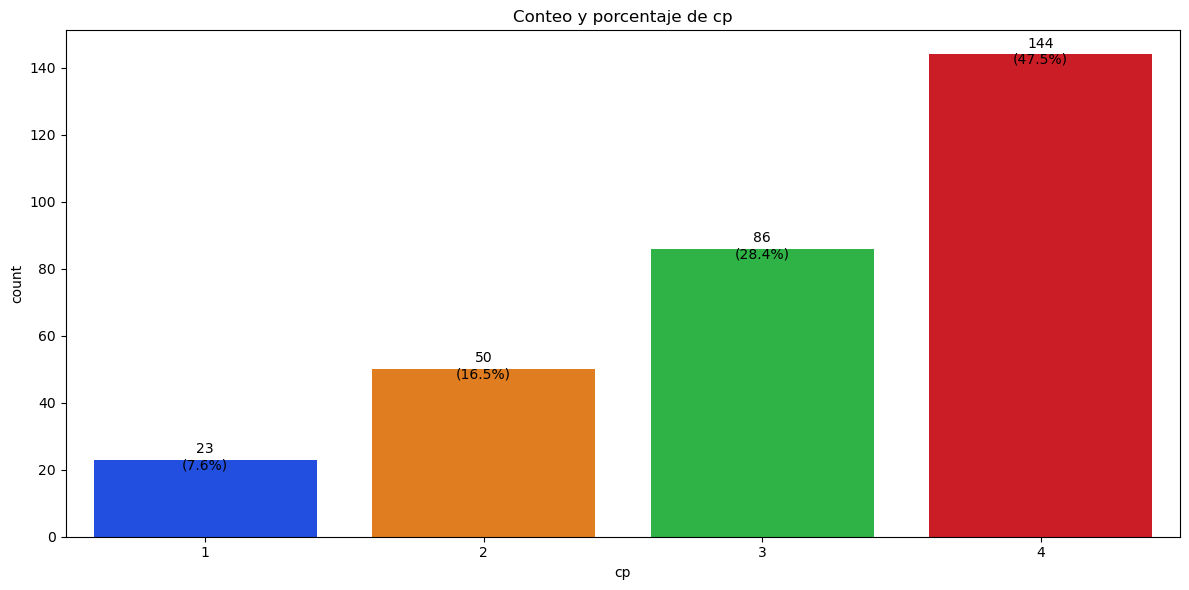


=== RESTECG ===


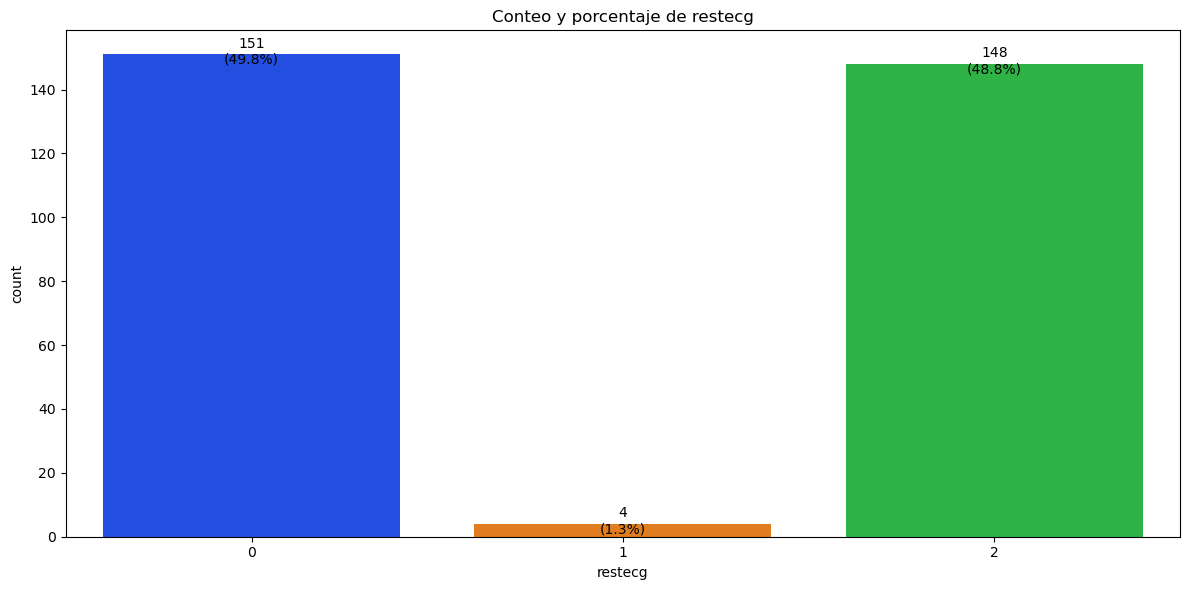


=== SLOPE ===


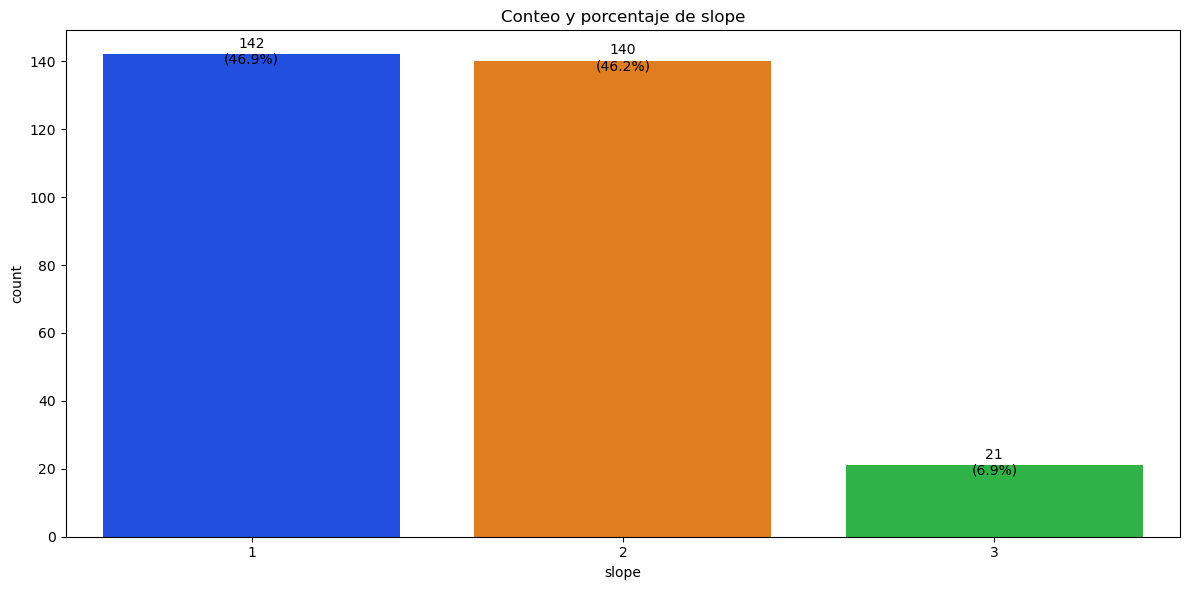


=== CA ===


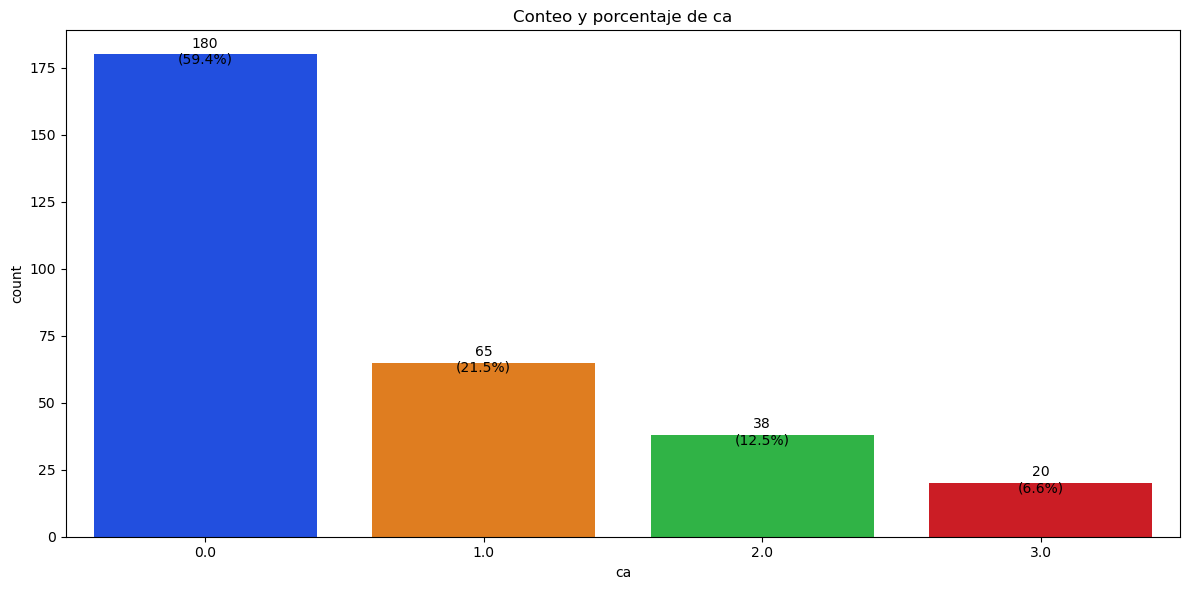


=== THAL ===


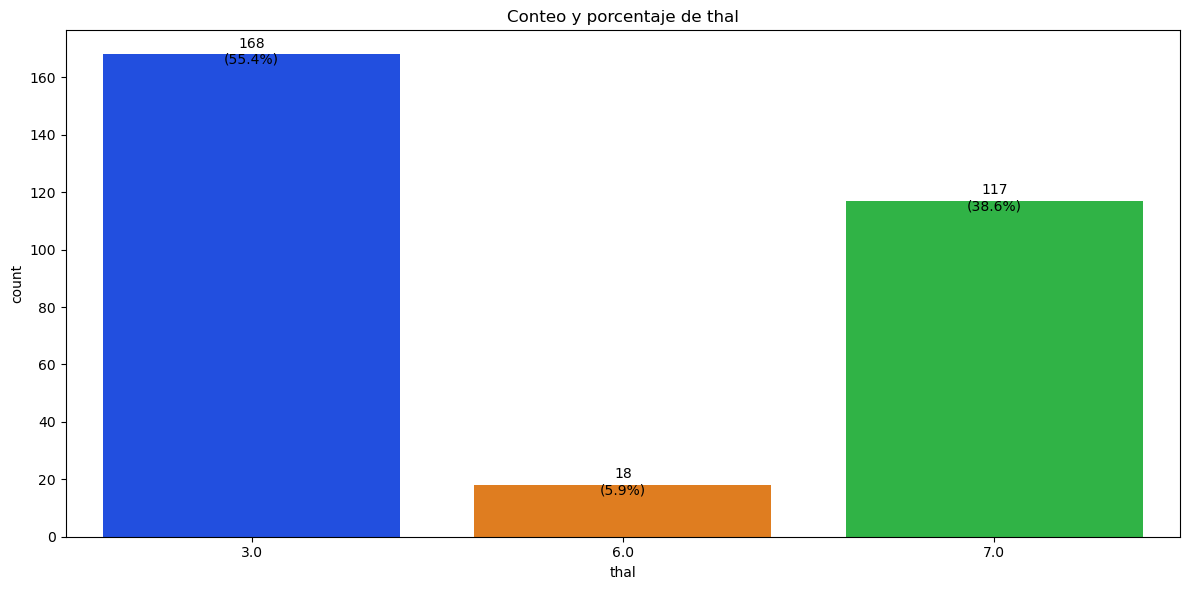

In [19]:
categoricas = ['cp', 'restecg', 'slope', 'ca', 'thal']

for col in categoricas:
    
    print(f"\n=== {col.upper()} ===")
    plt.figure(figsize=(12, 6))
    
    # Obtener el orden de las categorías según el diccionario
    value_order = sorted(df[col].unique())  
    
    # Crear el gráfico de barras ordenado
    ax = sns.countplot(x=df[col], order=value_order, palette='bright')
    
    for p in ax.patches:
        count = int(p.get_height())
        percent = 100 * p.get_height() / len(df[col])
        ax.annotate(f'{count}\n({percent:.1f}%)',
                    (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 2),
                    textcoords='offset points')
        
    plt.title(f'Conteo y porcentaje de {col}')
    
    plt.tight_layout()
    plt.show()

**Interpretación**

1. `cp` (Tipo de dolor torácico): La categoría predominante es el dolor no anginoso (valor 3), seguida por los casos asintomáticos (valor 4). La angina típica (valor 1) es la menos común. Esto sugiere que la mayoría de los pacientes no presenta síntomas clásicos de angina, lo que podría dificultar el diagnóstico clínico tradicional.

2. `restecg` (Resultados electrocardiográficos en reposo): Casi la mitad de los pacientes muestra anormalidades leves en el ECG en reposo, mientras que la otra mitad tiene resultados normales. Las anormalidades severas son muy raras (solo 1.3%). Esta variable podría ser un predictor relevante, especialmente si las anormalidades leves se asocian con la enfermedad.

3. `slope` (Pendiente del segmento ST en ejercicio):Las pendientes ascendente y plana son casi igualmente frecuentes, mientras que la pendiente descendente es poco común. La pendiente descendente (valor 3) es clínicamente significativa, ya que often se asocia con enfermedad coronaria.

4. `ca` (Número de vasos principales coloreados por fluoroscopia): La mayoría de los pacientes no muestra vasos afectados (valor 0). La enfermedad de un vaso es relativamente común, mientras que la afectación de múltiples vasos (2 o 3) es menos frecuente. Esta variable es críticamente importante, ya que cuantifica la severidad de la enfermedad arterial.

5. `thal` (Talasemia): Más de la mitad de los pacientes tiene un flujo sanguíneo normal (valor 3). Entre los casos anormales, el defecto reversible (valor 7) es mucho más común que el defecto fijo (valor 6). Los defectos reversibles a menudo están asociados con isquemia inducible, un marcador de enfermedad coronaria.

- Variables como `ca` y `thal` muestran distribuciones que reflejan la severidad de la enfermedad cardíaca en la población.
- La variable `cp` revela que la mayoría de los pacientes no presenta dolor torácico típico, lo que resalta la importancia de usar múltiples variables para el diagnóstico.
- La rareza de ciertas categorías (ej: `restecg = 2`, `slope = 3`) podría afectar el poder predictivo de esos niveles en modelos de machine learning, pero son clínicamente críticas.
- Estas distribuciones justifican el uso de técnicas como one-hot encoding para evitar que el modelo interprete erroneamente el orden numérico de las categorías.

### **Variables Númericas**

Se genera una tabla para visualizar algunos estadísticos descriptivos para las variables númericas.

In [20]:
numericas = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
df[numericas].describe()

,age,trestbps,chol,thalach,oldpeak
count,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,131.689769,246.693069,149.607261,1.039604
std,9.038662,17.599748,51.776918,22.875003,1.161075
min,29.000000,94.000000,126.000000,71.000000,0.000000
25%,48.000000,120.000000,211.000000,133.500000,0.000000
50%,56.000000,130.000000,241.000000,153.000000,0.800000
75%,61.000000,140.000000,275.000000,166.000000,1.600000
max,77.000000,200.000000,564.000000,202.000000,6.200000


**Interpretación**

1. `age` (Edad): La distribución de edad es relativamente simétrica (media y mediana cercanas). La mayoría de los pacientes se concentra entre los 48 y 61 años (rango intercuartílico), lo que sugiere que la enfermedad cardíaca en este dataset afecta predominantemente a personas de mediana edad.

2. `trestbps` (Presión arterial en reposo): La presión arterial en reposo muestra una distribución cercana a la normal (media y mediana casi idénticas). Los valores típicos (120-140 mm Hg) están dentro del límite prehipertensivo o hipertensión etapa 1, según estándares clínicos.

3. `chol` (Colesterol sérico): El colesterol presenta una distribución con ligero sesgo positivo (media > mediana). El 75% de los pacientes tiene niveles ≤ 275 mg/dl, pero existen valores extremos (hasta 564 mg/dl) que podrían corresponder a casos de hipercolesterolemia severa. El promedio supera el umbral saludable (<200 mg/dl).

4. `thalach` (Frecuencia cardíaca máxima alcanzada): La distribución tiene sesgo negativo (media < mediana), indicando que algunos pacientes tienen frecuencias cardíacas máximas bajas. El rango intercuartílico (133.5-166 lpm) es coherente con esfuerzo físico moderado en pruebas de estrés.

5. Variable: `oldpeak` (Depresión del segmento ST inducida por ejercicio): La distribución está altamente sesgada positivamente (media > mediana). El 25% de los pacientes no muestra depresión (oldpeak = 0), pero existen valores atípicos elevados (hasta 6.2). Valores > 1-2 son clínicamente significativos y sugieren isquemia inducible.

- Las variables numéricas muestran distribuciones heterogéneas: algunas simétricas (`trestbps`), otras sesgadas (`chol`, `oldpeak`).
- Valores atípicos potenciales están presentes en `chol` y `oldpeak`, lo que podría requerir imputación o transformación para modelado.
- Los promedios de `chol` y `trestbps` indican que la población estudiada tiene perfil de riesgo cardiovascular moderado-alto.
- La variabilidad en `thalach` y `oldpeak` refleja respuestas heterogéneas al ejercicio, útil para predecir enfermedad cardíaca.

Se genera un histograma y un boxplot para visualizar la distribución de frecuencias e identificar outliers (puntos fuera de los bigotes) y la dispersión de los datos. Además se evalua:

- **Asimetría**:
    - `skew = 0`: Distribución simétrica (valores aceptables skew $\in (-1,1)$).
    - `skew > 0`: Mayor peso en la cola izquierda de la distribución (sesgo positivo).
    - `skew < 0`: Mayor peso en la cola derecha de la distribución (sesgo negativo).

- **Kurtosis**: Determina si una distribución tiene colas gruesas con respecto a la distribución normal. Proporciona información sobre la forma de una distribución de frecuencias.
    - `kurtosis = 3`: se denomina mesocúrtica (distribución normal).
    - `kurtosis < 3`: se denomina platicúrtica (distribución con colas menos gruesas que la normal).
    - `kurtosis > 3`: se denomina leptocúrtica (distribución con colas más gruesas que la normal) y significa que trata de producir más valores atípicos que la distribución normal.

- **Coeficiente de Variación**: Es una medida estadística que se utiliza para evaluar la variabilidad relativa de una muestra en relación con su media. Se calcula como la desviación estándar de los datos dividida por la media, y se expresa como un porcentaje multiplicado por 100 para facilitar su interpretación.


=== AGE ===
Skew: -0.21
Kurtosis:  -0.52
Coeficiente de Variación:  16.6 %


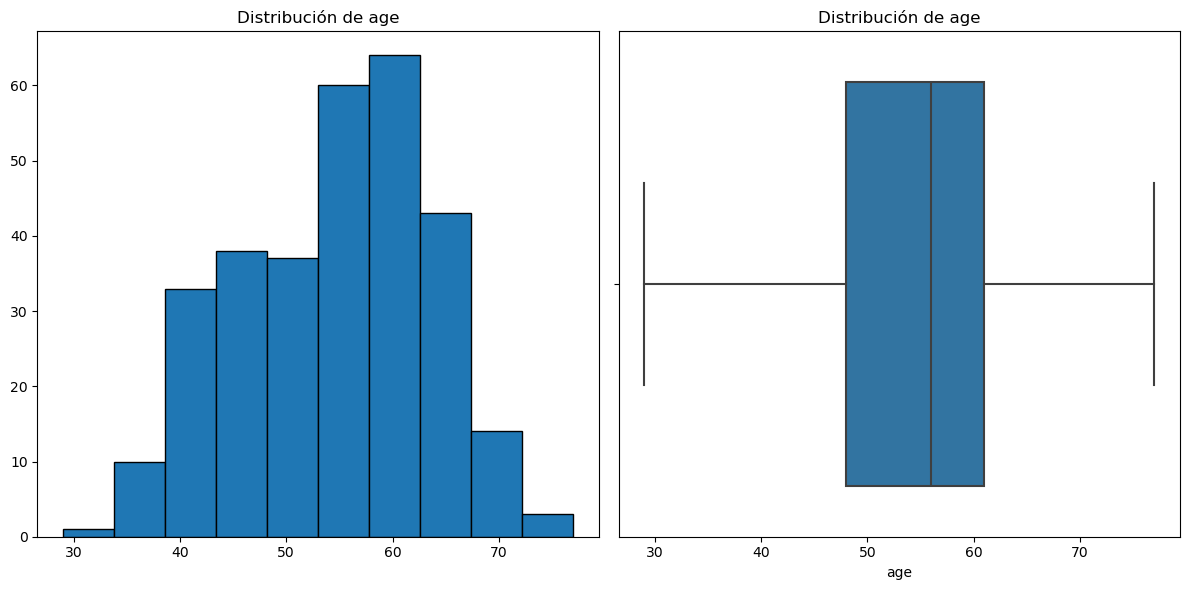


=== TRESTBPS ===
Skew: 0.71
Kurtosis:  0.88
Coeficiente de Variación:  13.36 %


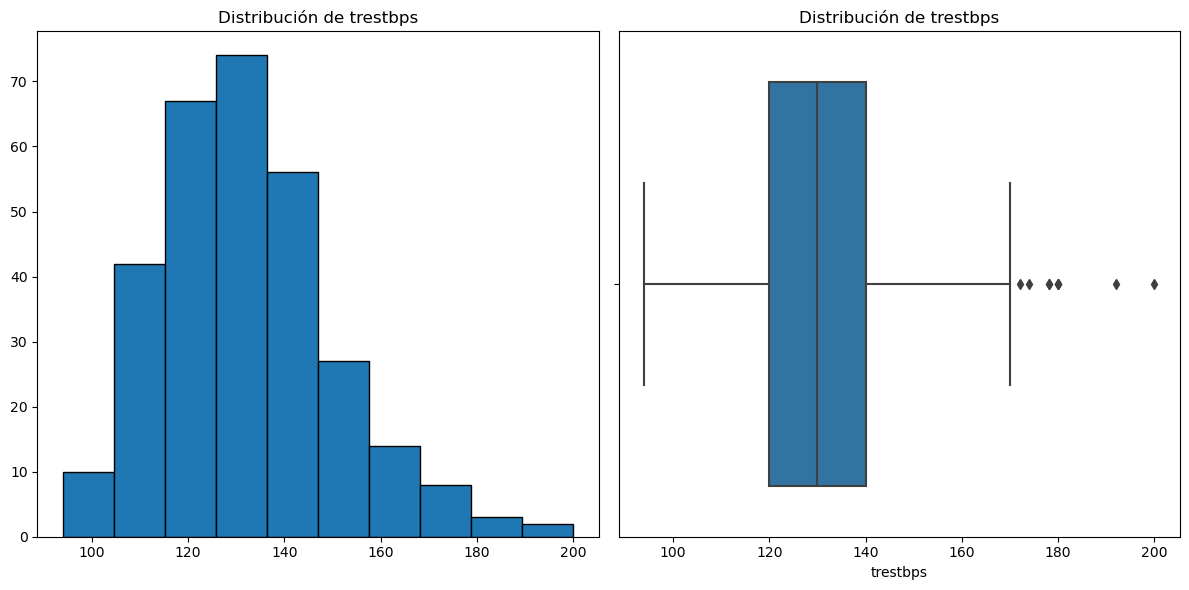


=== CHOL ===
Skew: 1.14
Kurtosis:  4.49
Coeficiente de Variación:  20.99 %


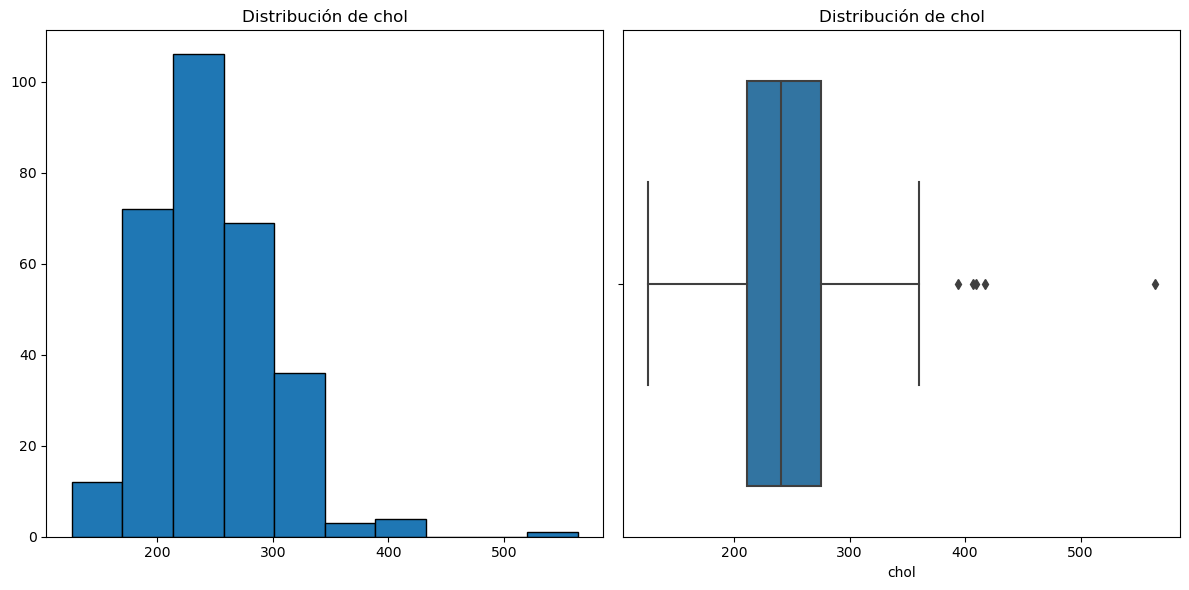


=== THALACH ===
Skew: -0.54
Kurtosis:  -0.05
Coeficiente de Variación:  15.29 %


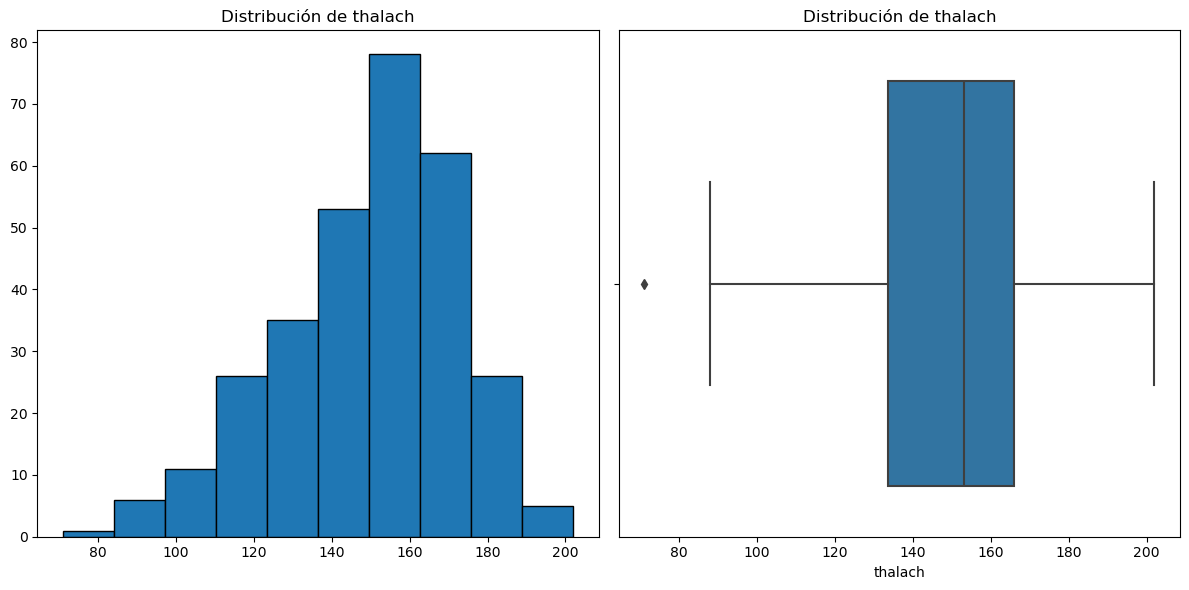


=== OLDPEAK ===
Skew: 1.27
Kurtosis:  1.58
Coeficiente de Variación:  111.68 %


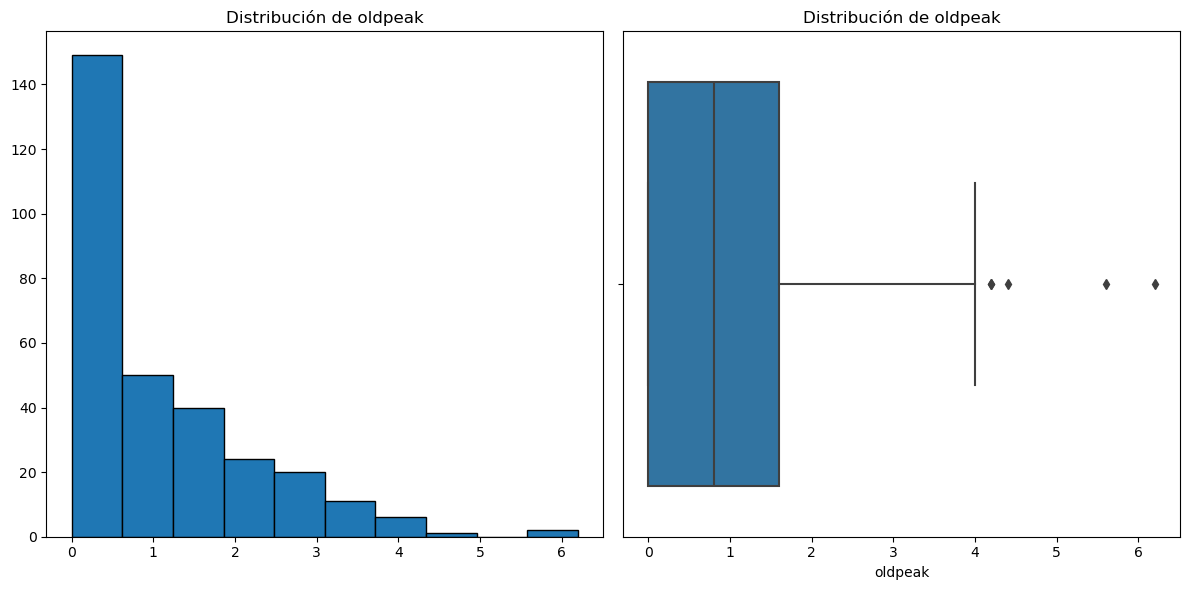

In [21]:
for col in numericas:
    
    print(f"\n=== {col.upper()} ===")
    print('Skew:', round(df[col].skew(), 2))
    print('Kurtosis: ', round(df[col].kurtosis(), 2))
    coef_variacion = (df[col].std()/ df[col].mean() ) * 100
    print('Coeficiente de Variación: ', round(coef_variacion, 2), '%')
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    df[col].hist(grid=False, edgecolor = "black")
    plt.title(f'Distribución de {col}')
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col])
    plt.title(f'Distribución de {col}')
    plt.tight_layout()
    plt.show()

**Interpretación**

1. `age` (Edad)
    - **Skewness (-0.21):** Distribución ligeramente sesgada a la izquierda. La cola izquierda es más larga que la derecha, significa que hay una concentración leve de pacientes más jóvenes.
    - **Kurtosis (-0.52):** Distribución platicúrtica (más plana que la normal). Los datos están menos concentrados alrededor de la media y tienen colas más ligeras, indicando mayor dispersión sin valores extremos pronunciados.
    - **Coeficiente de Variación (16.6%):** Dispersión moderada relativa a la media. La edad varía moderadamente entre pacientes.

2. `trestbps` (Presión arterial en reposo)
    - **Skewness (0.71):** Distribución moderadamente sesgada a la derecha. La cola derecha es más larga, indicando que algunos pacientes tienen valores de presión arterial más altos que el promedio.
    - **Kurtosis (0.88):** Distribución leptocúrtica (más picada que la normal). Los datos están más concentrados alrededor de la media, pero con colas más pesadas (presencia de valores más extremos).
    - **Coeficiente de Variación (13.36%):** Dispersión baja relativa a la media. La presión arterial es relativamente consistente en la mayoría de los pacientes.

3. `chol` (Colesterol sérico)**
    - **Skewness (1.14):** Distribución altamente sesgada a la derecha. La cola derecha es muy larga, confirmando la presencia de valores atípicos altos (hipercolesterolemia severa).
    - **Kurtosis (4.49):** Distribución muy leptocúrtica. Alta concentración alrededor de la media pero con colas extremadamente pesadas (valores atípicos significativos).
    - **Coeficiente de Variación (20.99%):** Dispersión alta relativa a la media. El colesterol varía considerablemente entre pacientes, con valores desde normales hasta muy altos.

4. `thalach` (Frecuencia cardíaca máxima)
    - **Skewness (-0.54):** Distribución moderadamente sesgada a la izquierda. La cola izquierda es más larga, indicando que algunos pacientes tienen frecuencias cardíacas máximas más bajas.
    - **Kurtosis (-0.05):** Distribución muy cercana a la normal (mesocúrtica). La forma es casi perfectamente normal, con colas balanceadas.
    - **Coeficiente de Variación (15.29%):** Dispersión moderada. La frecuencia cardíaca máxima varía de manera esperada para una población con condiciones cardiovasculares diversas.

5. `oldpeak` (Depresión del segmento ST)
    - **Skewness (1.27):** Distribución muy sesgada a la derecha. La cola derecha es extremadamente larga, confirmando la presencia de valores altos atípicos (depresión severa inducida por ejercicio).
    - **Kurtosis (1.58):** Distribución leptocúrtica. Datos concentrados alrededor de la media pero con colas pesadas (valores extremos positivos).
    - **Coeficiente de Variación (111.68%):** Dispersión extremadamente alta. La variable es altamente variable entre pacientes, con muchos valores cercanos a 0 pero otros muy altos. Esto indica que mientras la mayoría no tiene depresión, algunos casos son severos.

- **Variables cercanas a la normalidad:** `thalach` es la más simétrica y con kurtosis cercana a cero.
- **Variables con sesgo positivo y outliers:** `chol` y `oldpeak` muestran sesgo pronunciado y kurtosis alta, indicando la necesidad de manejo de outliers para modelos sensibles.
- **Dispersión relativa:** `oldpeak` tiene la mayor variabilidad relativa (CV > 100%), lo que la convierte en un potencial discriminador fuerte para la enfermedad.

### **Análisis de Valores Atípicos**

Para la identificación de valores atípicos en las variables númericas, se aplicó el método del rango intercuartílico (IQR). 

In [22]:
for col in numericas:
    
    print(f"\n=== {col.upper()} ===")
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df[(df[col] < limite_inferior) | (df[col] > limite_superior)]
    print(f"Número de outliers: {len(outliers)}")
    print(f"Porcentaje de outliers: {len(outliers)/len(df)*100:.2f}%")
    if not outliers.empty:
        print(f"Valores atípicos: {outliers[col].tolist()}")
    else:
        print("No hay outliers")


=== AGE ===
Número de outliers: 0
Porcentaje de outliers: 0.00%
No hay outliers

=== TRESTBPS ===
Número de outliers: 9
Porcentaje de outliers: 2.97%
Valores atípicos: [172, 180, 200, 174, 178, 192, 180, 178, 180]

=== CHOL ===
Número de outliers: 5
Porcentaje de outliers: 1.65%
Valores atípicos: [417, 407, 564, 394, 409]

=== THALACH ===
Número de outliers: 1
Porcentaje de outliers: 0.33%
Valores atípicos: [71]

=== OLDPEAK ===
Número de outliers: 5
Porcentaje de outliers: 1.65%
Valores atípicos: [6.2, 5.6, 4.2, 4.2, 4.4]


**Interpretación**

1. `age` (Edad): No se detectaron valores atípicos. Esto confirma que todas las edades de los pacientes se encuentran dentro del rango esperado según la distribución IQR, sin registros extremos de juventud o vejez que distorsionen el análisis.

2. `trestbps` (Presión arterial en reposo): Los outliers corresponden a **valores de presión arterial elevados** (≥172 mm Hg), clasificables como hipertensión etapa 2 o crisis hipertensiva. Su presencia es clínicamente relevante, ya que la hipertensión severa es un factor de riesgo cardiovascular conocido.

3. Variable: `chol` (Colesterol sérico): Todos los outliers superan ampliamente el umbral de colesterol alto (>240 mg/dl), llegando a casos extremos de hipercolesterolemia (ej: 564 mg/dl). Estos valores son clínicamente críticos y consistentes con condiciones como hiperlipidemia familiar.

4. Variable: `thalach` (Frecuencia cardíaca máxima): El valor 71 lpm es **anormalmente bajo** para una frecuencia cardíaca máxima alcanzada durante ejercicio. Su rareza (solo 1 caso) sugiere que podría manejarse sin afectar significativamente el modelo.

5. `oldpeak` (Depresión del segmento ST): Estos valores representan **depresiones severas del segmento ST** (>4.0 mm), un hallazgo electrocardiográfico altamente sugestivo de isquemia miocárdica grave o infarto, son médicamente significativos.

- La mayoría de los valores atípicos no son errores, sino **casos médicamente relevantes** que enriquecen el dataset.

#### **Manejo de Valores Atípicos mediante Winsorization**

Para mitigar el impacto de valores extremos en variables numéricas críticas (`trestbps`, `chol`, `oldpeak`) identificadas previamente en el análisis de outliers, se aplicó la técnica de winsorization. Este método preserva los casos atípicos reemplazando los valores en los percentiles extremos superior e inferior por los valores en un límite especificado, reduciendo así la distorsión en los modelos sin eliminar registros valiosos. Los límites se establecieron en 2% para `trestbps` y 1% para `chol` y `oldpeak`, equilibrando la retención de información clínicamente relevante con la estabilidad estadística del modelo.

In [23]:
df['trestbps'] = winsorize(df['trestbps'], limits=[0.02, 0.02])  
df['chol'] = winsorize(df['chol'], limits=[0.01, 0.01]) 
df['oldpeak'] = winsorize(df['oldpeak'], limits=[0.01, 0.01])

Se verfican los cambios realizados.

In [24]:
numericas_atipicos =["trestbps","chol","oldpeak"]
df[numericas_atipicos].describe()

,trestbps,chol,oldpeak
count,303.000000,303.000000,303.000000
mean,131.610561,246.297030,1.027723
std,17.046299,48.832097,1.119258
min,101.000000,149.000000,0.000000
25%,120.000000,211.000000,0.000000
50%,130.000000,241.000000,0.800000
75%,140.000000,275.000000,1.600000
max,178.000000,407.000000,4.200000


**Interpretación**

1. `trestbps` (Presión arterial en reposo)**
    - **Mínimo:** Aumentó de **94** a **101** mm Hg.
    - **Máximo:** Disminuyó de **200** a **178** mm Hg.
    - **Desviación estándar:** Reducción leve de **17.60** a **17.05**.
    - **Interpretación:** La winsorization recortó los valores extremos en ambos extremos de la distribución. El nuevo máximo (178 mm Hg) indica que los casos de hipertensión severa (>178 mm Hg) fueron ajustados a este límite, reduciendo su impacto sin eliminarlos. La distribución ahora es más compacta, pero aún conserva la variabilidad clínicamente relevante.

2. `chol` (Colesterol sérico)
    - **Mínimo:** Aumentó de **126** a **149** mg/dl.
    - **Máximo:** Disminuyó drasticamente de **564** a **407** mg/dl.
    - **Desviación estándar:** Reducción de **51.78** a **48.83**.
    - **Interpretación:** Los valores extremos superiores (hipercolesterolemia severa >407 mg/dl) fueron winsorizados, lo que explica la notable reducción del máximo. Esto atenúa el sesgo positivo extremo de la variable, haciendo la distribución más simétrica y manejable para modelos sensibles a outliers, sin perder la señal de colesterol elevado.

3. Variable: `oldpeak` (Depresión del segmento ST)
    - **Máximo:** Reducción significativa de **6.2** a **4.2**.
    - **Desviación estándar:** Leve disminución de **1.16** a **1.12**.
    - **Interpretación:** Los valores de depresión severa del segmento ST (>4.2) fueron ajustados al límite superior winsorizado. Esto es clínicamente razonable, ya que valores superiores a 4.0 mm son altamente anormales y su reducción controla su influencia desproporcionada en el modelo, mientras se mantiene su valor como predictor crítico.

- **Reducción de sesgo:** La winsorization mitigó efectivamente el impacto de los valores extremos en las tres variables, como evidencia la disminución de la desviación estándar en todas ellas.
- **Preservación de información:** Los valores winsorizados aún capturan la esencia clínica de los outliers (ej: presión arterial alta y colesterol elevado) pero en un rango menos extremo.
- **Mejora para modelado:** Las distribuciones resultantes son más robustas para modelos lineales (regresión logística) que asumen normalidad y homocedasticidad, ya que los outliers ya no ejercerán leverage excesivo.
- **Límites adecuados:** Los parámetros de winsorization (1-2%) fueron apropiados, ya que lograron reducir la influencia de outliers sin truncar masivamente la distribución original.

#### **Verificación Visual del Efecto de la Winsorization**

Para evaluar visualmente el impacto de la winsorization en la distribución y dispersión de las variables tratadas (`trestbps`, `chol`, `oldpeak`), se generaron histogramas y diagramas de caja (boxplots). Estas visualizaciones permiten contrastar las distribuciones antes y después del tratamiento, confirmando la reducción de valores extremos mientras se mantiene la estructura central de los datos, asegurando así la preparación adecuada para el modelado. Además se evalua nuevamente:

- **Asimetría**:
    - `skew = 0`: Distribución simétrica (valores aceptables skew $\in (-1,1)$).
    - `skew > 0`: Mayor peso en la cola izquierda de la distribución (sesgo positivo).
    - `skew < 0`: Mayor peso en la cola derecha de la distribución (sesgo negativo).

- **Kurtosis**: Determina si una distribución tiene colas gruesas con respecto a la distribución normal. Proporciona información sobre la forma de una distribución de frecuencias.
    - `kurtosis = 3`: se denomina mesocúrtica (distribución normal).
    - `kurtosis < 3`: se denomina platicúrtica (distribución con colas menos gruesas que la normal).
    - `kurtosis > 3`: se denomina leptocúrtica (distribución con colas más gruesas que la normal) y significa que trata de producir más valores atípicos que la distribución normal.

- **Coeficiente de Variación**: Es una medida estadística que se utiliza para evaluar la variabilidad relativa de una muestra en relación con su media. Se calcula como la desviación estándar de los datos dividida por la media, y se expresa como un porcentaje multiplicado por 100 para facilitar su interpretación.


=== TRESTBPS ===
Skew: 0.58
Kurtosis:  0.18
Coeficiente de Variación:  12.95 %


<Figure size 1200x600 with 0 Axes>

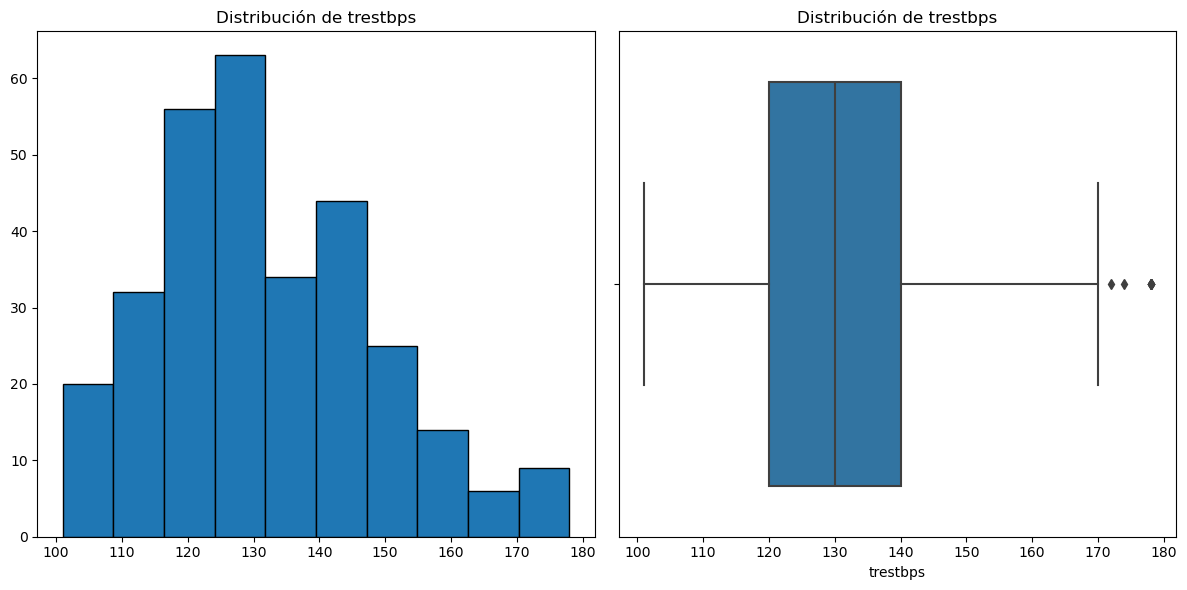


=== CHOL ===
Skew: 0.6
Kurtosis:  0.6
Coeficiente de Variación:  19.83 %


<Figure size 1200x600 with 0 Axes>

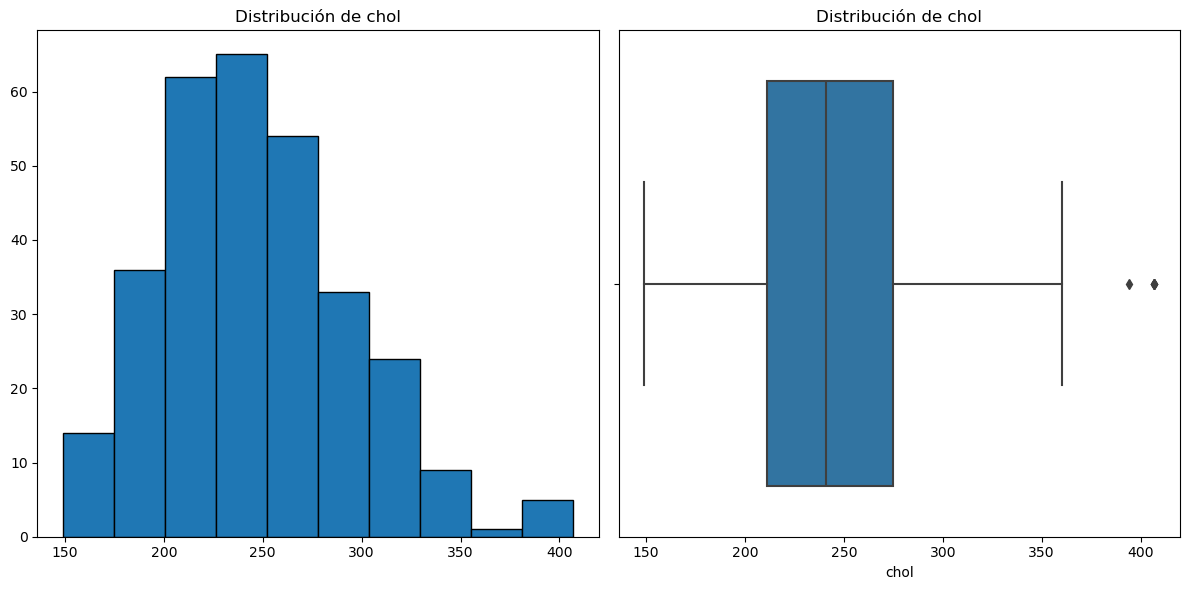


=== OLDPEAK ===
Skew: 1.03
Kurtosis:  0.26
Coeficiente de Variación:  108.91 %


<Figure size 1200x600 with 0 Axes>

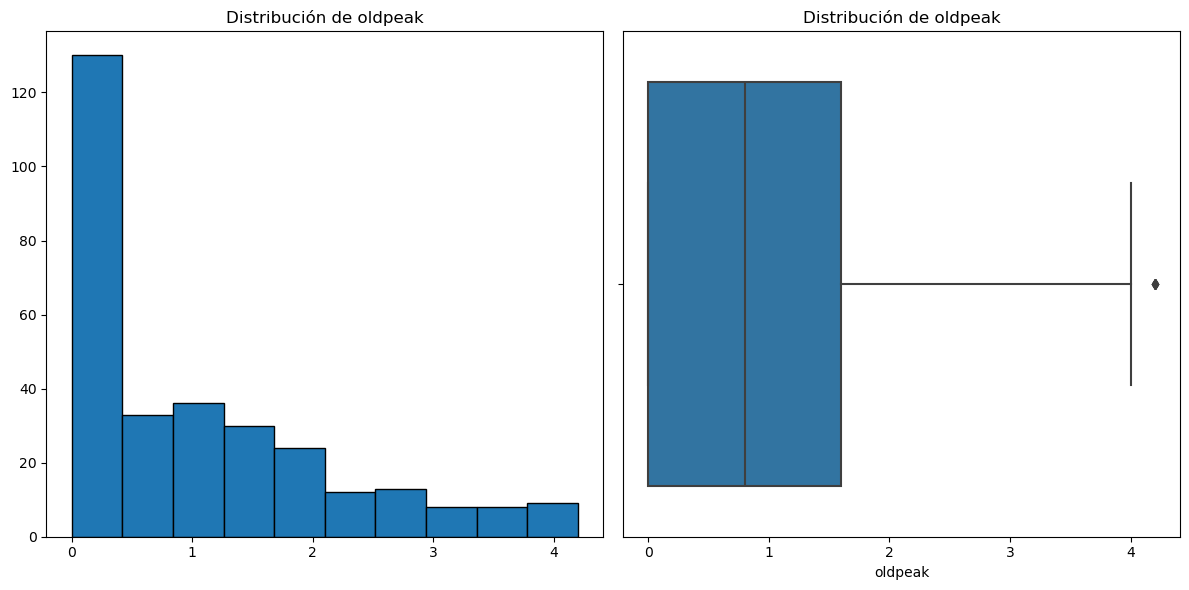

In [25]:
for col in numericas_atipicos:
    
    print(f"\n=== {col.upper()} ===")
    plt.figure(figsize=(12, 6))
    print('Skew:', round(df[col].skew(), 2))
    print('Kurtosis: ', round(df[col].kurtosis(), 2))
    coef_variacion = (df[col].std()/ df[col].mean() ) * 100
    print('Coeficiente de Variación: ', round(coef_variacion, 2), '%')
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    df[col].hist(grid=False, edgecolor = "black")
    plt.title(f'Distribución de {col}')
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col])
    plt.title(f'Distribución de {col}')
    plt.tight_layout()
    plt.show()

**Interpretación**

1. `trestbps` (Presión arterial en reposo)
    - **Skewness (0.58):** El sesgo se redujo (de 0.71 a 0.58), indicando una distribución menos asimétrica a la derecha. La winsorization mitigó la influencia de los valores extremos altos.
    - **Kurtosis (0.18):** La curtosis disminuyó significativamente (de 0.88 a 0.18), acercándose a 0 (mesocúrtica). Esto sugiere que la distribución ahora es más similar a una normal, con colas menos pesadas y menor concentración de valores extremos.
    - **Coeficiente de Variación (12.95%):** La dispersión relativa disminuyó ligeramente (de 13.36% a 12.95%), confirmando que la variable es más estable y consistente después del tratamiento.

2. `chol` (Colesterol sérico)
    - **Skewness (0.6):** El sesgo se redujo drasticamente (de 1.14 a 0.6), indicando una distribución mucho más simétrica. La winsorization corrigió eficientemente la asimetría positiva extrema causada por los outliers.
    - **Kurtosis (0.6):** La curtosis disminuyó notablemente (de 4.49 a 0.6), acercándose a una distribución normal. Esto refleja una reducción significativa en la frecuencia de valores extremos y una distribución más balanced.
    - **Coeficiente de Variación (19.83%):** La dispersión relativa se redujo (de 20.99% a 19.83%), indicando que la variabilidad de los datos es ahora más homogénea y menos influenciada por outliers.

3. `oldpeak` (Depresión del segmento ST)
    - **Skewness (1.03):** El sesgo disminuyó (de 1.27 a 1.03), pero sigue siendo moderadamente positivo. Esto era esperado debido a la naturaleza inherentemente sesgada de esta variable clínica.
    - **Kurtosis (0.26):** La curtosis se redujo significativamente (de 1.58 a 0.26), indicando que la distribución ahora tiene colas más ligeras y es menos picuda. Los valores extremos superiores fueron controlados.
    - **Coeficiente de Variación (108.91%):** La dispersión relativa disminuyó ligeramente (de 111.68% a 108.91%), pero sigue siendo muy alta. Esto confirma que `oldpeak` sigue siendo una variable con alta variabilidad inherente, incluso después de winsorization.

- **Efectividad de la winsorization:** El método fue altamente efectivo para reducir el sesgo y la curtosis en `trestbps` y `chol`, haciendo sus distribuciones más adecuadas para modelos que suponen normalidad.
- **Mejora en la estabilidad:** La reducción en el coeficiente de variación en todas las variables indica una mayor consistencia en los datos, lo que mejorará la performance de modelos sensibles a outliers.
- **Naturaleza persistente de `oldpeak`:** Aunque la winsorization ayudó, `oldpeak` mantuvo su alto sesgo y variabilidad. Esto refleja su naturaleza clínica: la mayoría de los pacientes tiene poca o ninguna depresión del ST, pero algunos casos severos persisten (aunque menos extremos).
- **Impacto en el modelado:** Las variables tratadas son ahora más robustas para modelos lineales, y capturarán la esencia clínica de los datos originales.

## **Análisis Bivariado**

El análisis bivariado es la segunda fase del análisis exploratorio de datos. Se enfoca en las relaciones entre dos variables para obtener datos estadísticos sobre sus influencias mutuas.

### **Variables Binarias vs Num**

Se generan graficos de barras para analizar la relación entre un conjunto de variables binarias y la presencia de enfermedad cardíaca con el fin de identificar qué variables binarias están asociadas a mayores proporciones de diagnóstico positivos en el conjunto de datos.

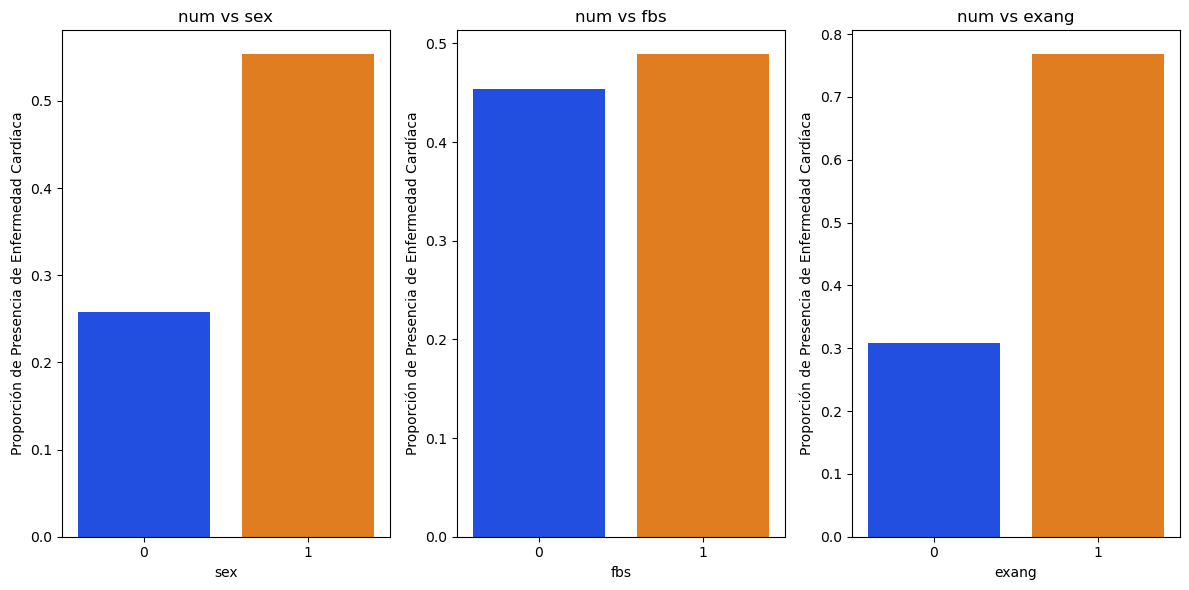

In [26]:
plt.figure(figsize=(12, 6)) 

for i, col in enumerate(binarias, 1):  
    if col != "num":
        plt.subplot(1, 3, i) 
        sns.barplot(
        x=col, 
        y='num', 
        data=df, 
        palette='bright',
        errorbar=None
        )
        plt.title(f'num vs {col}')
        plt.ylabel('Proporción de Presencia de Enfermedad Cardíaca')
plt.tight_layout()  
plt.show()

**Interpretación**

1. **num vs sex (sexo)**

   * `0` = mujeres, `1` = hombres.
   * La proporción de enfermedad cardíaca es claramente más alta en hombres (alrededor de 0.55) que en mujeres (alrededor de 0.26).
   * **Interpretación**: en este dataset, los hombres presentan una mayor probabilidad de enfermedad cardíaca que las mujeres.

2. **num vs fbs (fbs: fasting blood sugar > 120 mg/dl)**

   * `0` = no, `1` = sí.
   * Las proporciones son bastante similares (aprox. 0.45 para `fbs=0` y 0.49 para `fbs=1`).
   * **Interpretación**: el nivel de azúcar en ayunas alto no muestra una diferencia marcada en la presencia de enfermedad cardíaca en este dataset. Su valor predictivo parece limitado.

3. **num vs exang (exercise induced angina)**

   * `0` = no, `1` = sí.
   * Quienes presentan angina inducida por ejercicio (`exang=1`) tienen una proporción muy alta de enfermedad cardíaca (~0.77), frente a los que no la presentan (~0.31).
   * **Interpretación**: la presencia de angina inducida por ejercicio está fuertemente asociada con la enfermedad cardíaca, por lo que puede ser un factor muy relevante para el modelo predictivo.

* **Sexo (hombres)** y especialmente **angina inducida por ejercicio** son variables con una relación fuerte con la enfermedad cardíaca.
* **Azúcar en ayunas** no parece aportar demasiada diferenciación en este dataset.

### **Variables Categóricas vs Num**

Se generan graficos de barras para analizar la relación entre variables categóricas y la presencia de enfermedad cardíaca en la población estudiada. Con el fin de identificar qué categorías dentro de cada variable presentan mayores proporciones de diagnósticos positivos, lo que podría indicar posibles factores de riesgo asociados.


=== CP ===


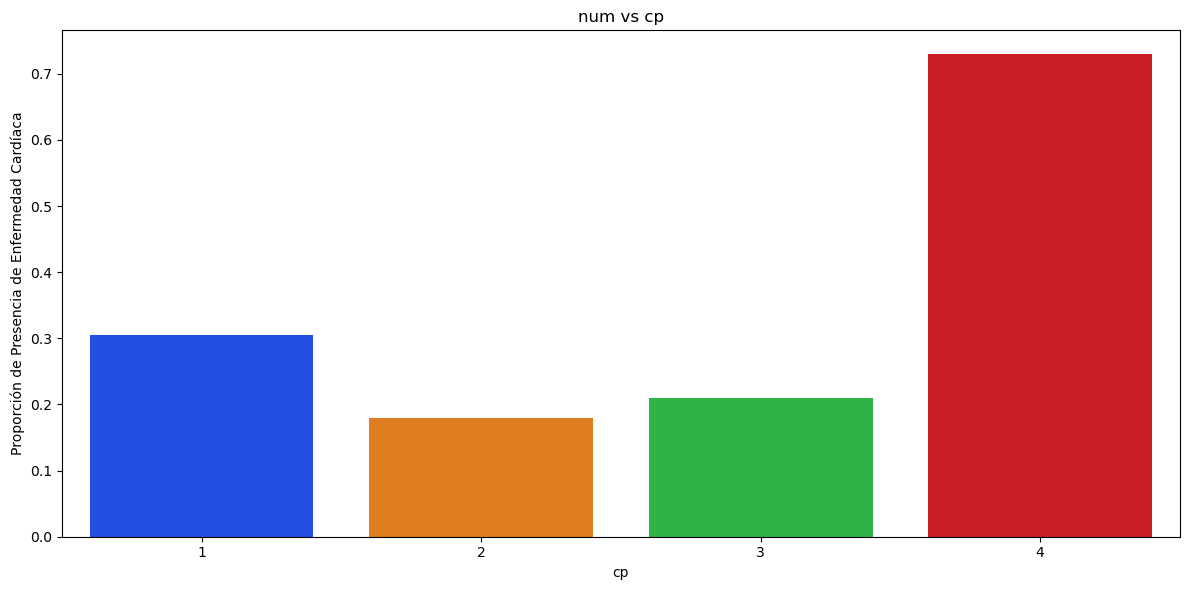


=== RESTECG ===


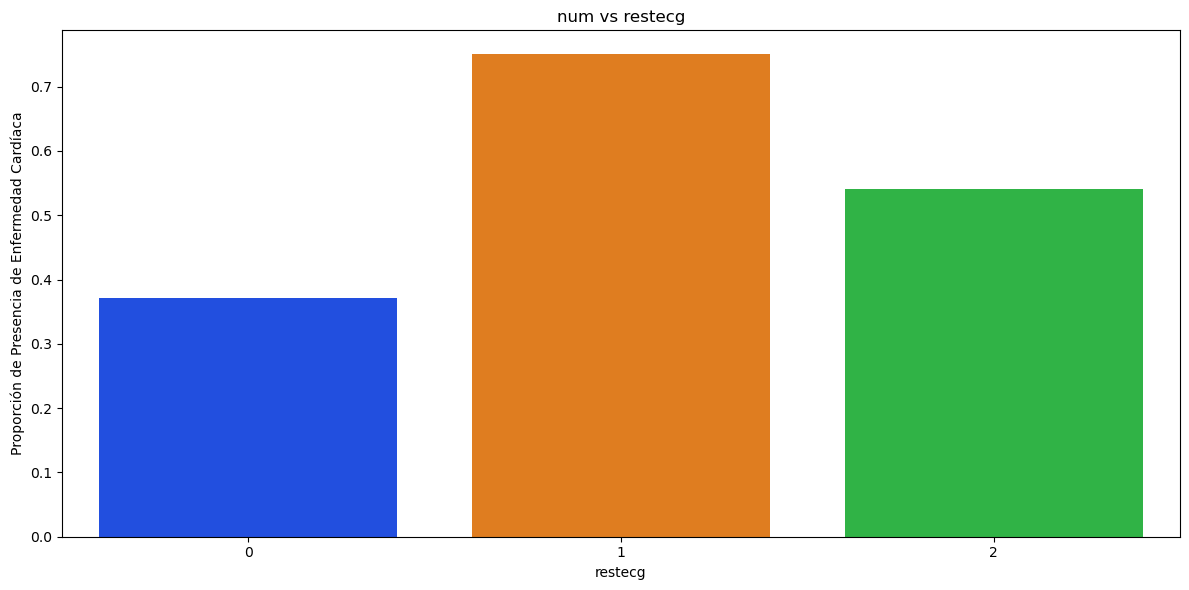


=== SLOPE ===


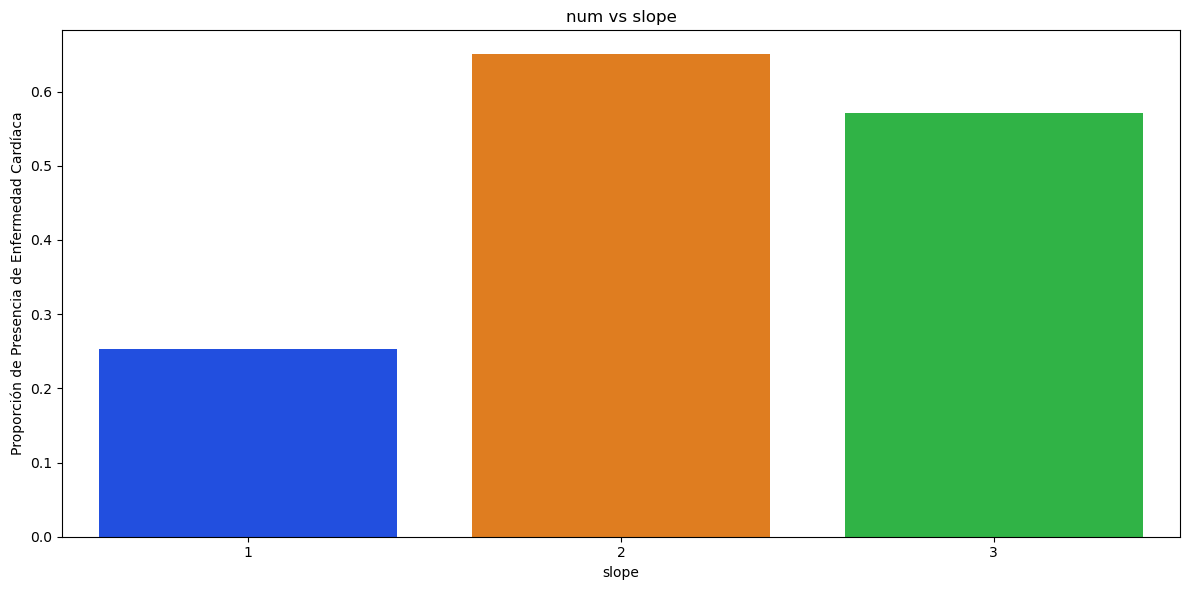


=== CA ===


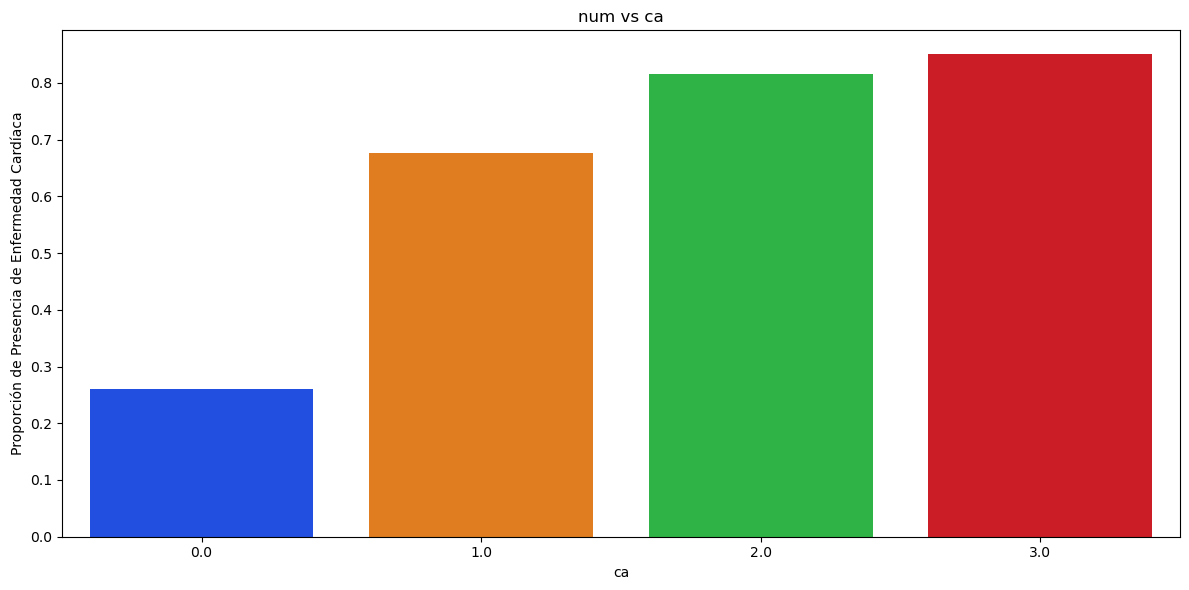


=== THAL ===


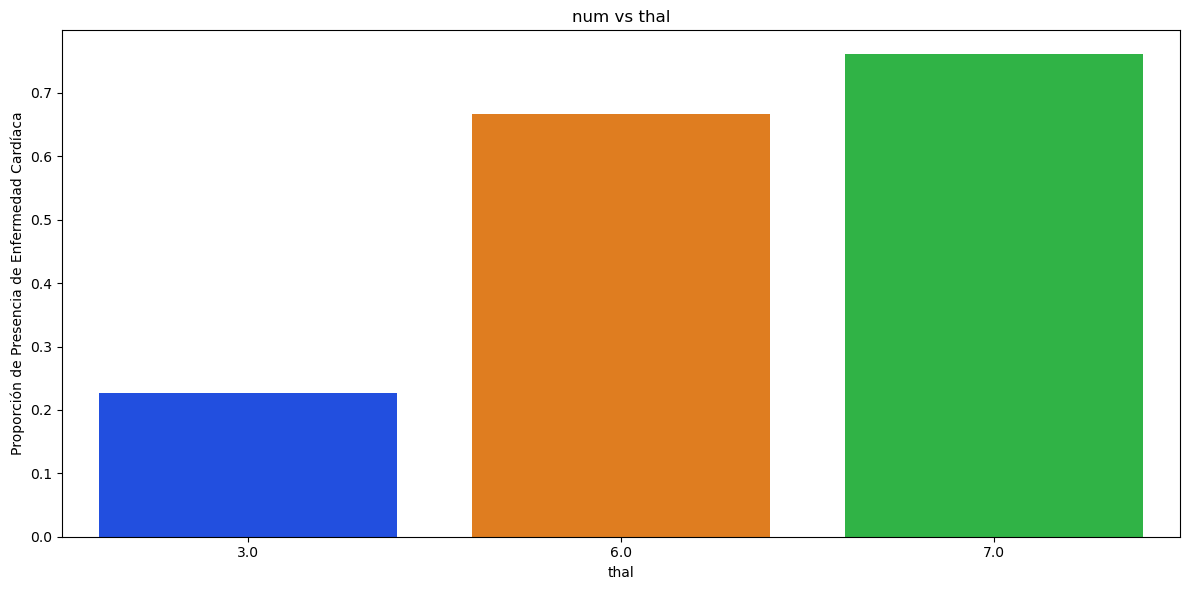

In [27]:
for col in categoricas:
    
    print(f"\n=== {col.upper()} ===")
    plt.figure(figsize=(12, 6))
    sns.barplot(
        x=col, 
        y='num', 
        data=df, 
        palette='bright',
        errorbar=None  
    )

    plt.title(f'num vs {col}')
    plt.ylabel('Proporción de Presencia de Enfermedad Cardíaca')
    plt.tight_layout()
    plt.show()
    

**Interpretación**

1. **num vs cp (tipo de dolor en el pecho)**

  * `cp` indica el tipo de dolor torácico (1: angina típica, 2: angina atípica, 3: dolor no anginoso, 4: asintomático).
  * La proporción de enfermedad cardíaca es:
    * Más baja en **angina atípica (2)** y **dolor no anginoso (3)** (~0.18 y ~0.21).
    * Moderada en **angina típica (1)** (~0.31).
    * Muy alta en **asintomáticos (4)** (~0.73).
  * **Interpretación**: Los pacientes sin dolor (asintomáticos) tienen más probabilidad de tener enfermedad cardíaca, lo que refleja el riesgo oculto cuando no hay síntomas claros.

2. **num vs restecg (electrocardiograma en reposo)**

  * Valores: `0` = normal, `1` = anomalía de la onda ST-T, `2` = hipertrofia ventricular izquierda.
  * La proporción de enfermedad cardíaca es:
    * ~0.37 en **ECG normal (0)**.
    * ~0.75 en **anomalía de ST-T (1)**.
    * ~0.54 en **hipertrofia ventricular izquierda (2)**.
  * **Interpretación**: Las anomalías en el ECG, especialmente en ST-T, están fuertemente asociadas a la enfermedad cardíaca.

3. **num vs slope (pendiente del segmento ST en ejercicio máximo)**

  * `1` = ascendente, `2` = plana, `3` = descendente.
  * Proporción de enfermedad cardíaca:
    * Más baja con pendiente **ascendente (1)** (~0.25).
    * Mucho más alta con pendiente **plana (2)** (~0.65) y **descendente (3)** (~0.57).
  * **Interpretación**: Una pendiente ST plana o descendente es un marcador claro de mayor riesgo de enfermedad cardíaca.

4. **num vs ca (número de vasos principales coloreados por fluoroscopía)**

  * Valores de 0 a 3.
  * La proporción de enfermedad cardíaca aumenta conforme el número de vasos coloreados:
    * **0 vasos**: ~0.26.
    * **1 vaso**: ~0.68.
    * **2 vasos**: ~0.81.
    * **3 vasos**: ~0.85.
  * **Interpretación**: A mayor número de vasos afectados visibles en la fluoroscopía, mayor la probabilidad de enfermedad cardíaca. Este es uno de los predictores más fuertes.

5. **num vs thal (Talasemia)** Proporción de enfermedad por categoría:

    - **thal=3** (Normal): ~23% de enfermedad cardíaca.
    - **thal=6** (Defecto fijo): ~68% de enfermedad cardíaca.
    - **thal=7** (Defecto reversible): ~75% de enfermedad cardíaca.
  - **Interpretación**: Los defectos reversibles (thal=7) tienen la mayor asociación con enfermedad cardíaca, seguido por los defectos fijos (thal=6). El flujo normal (thal=3) tiene la menor proporción.

### Variables Númericas vs Num

Con el objetivo de identificar la relación entre las variables numéricas predictoras y la variable objetivo (`num`), se genera una serie de diagramas de caja (boxplots). Esta visualización permite comparar la distribución (mediana, rango intercuartílico) de cada variable numérica segmentada por la clase de diagnóstico, facilitando la observación de diferencias significativas entre los grupos que podrían ser patrones predictivos clave.


=== AGE ===


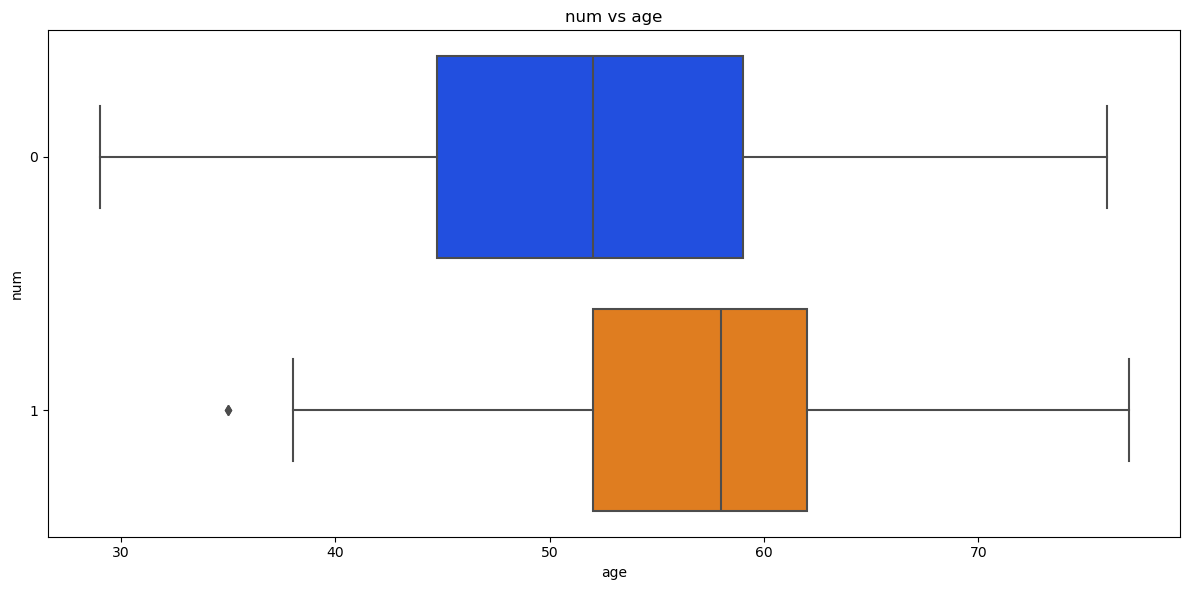


=== TRESTBPS ===


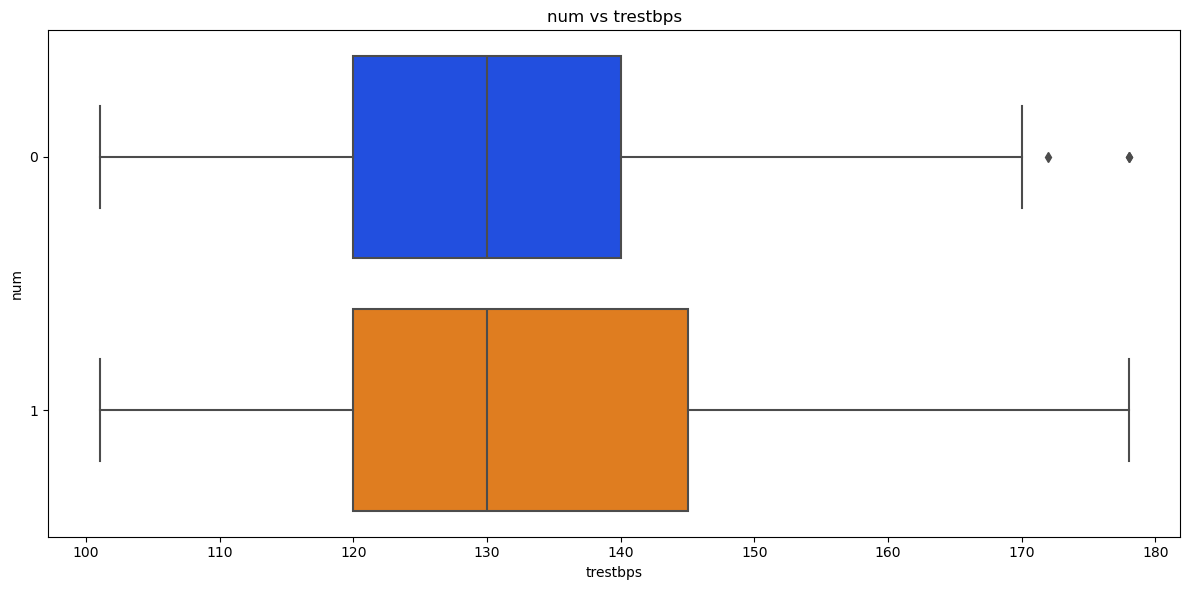


=== CHOL ===


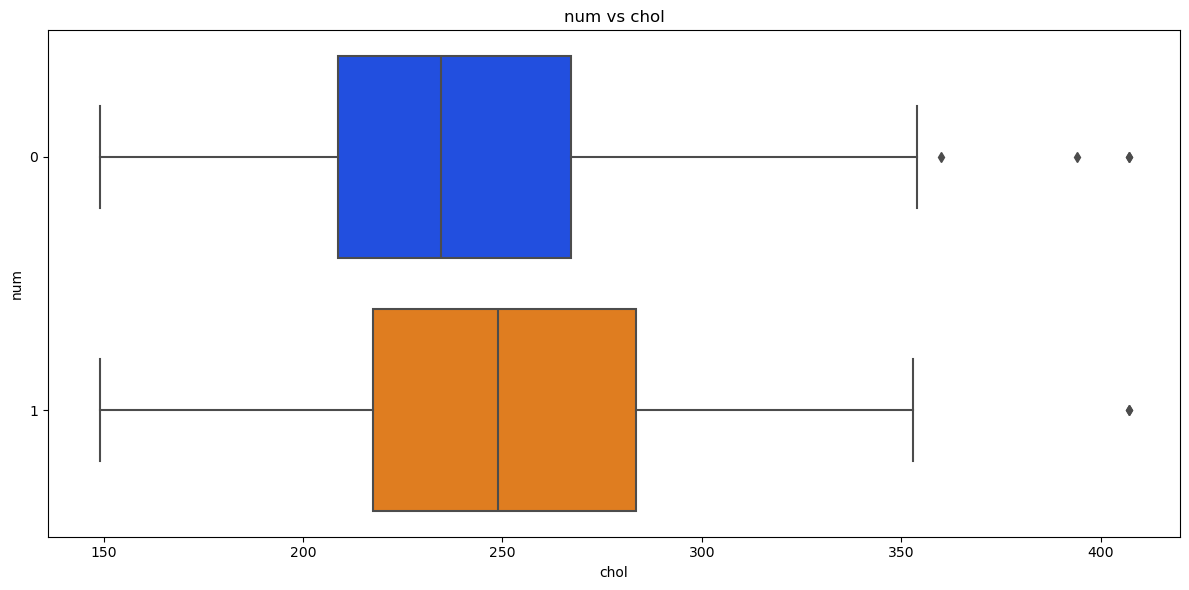


=== THALACH ===


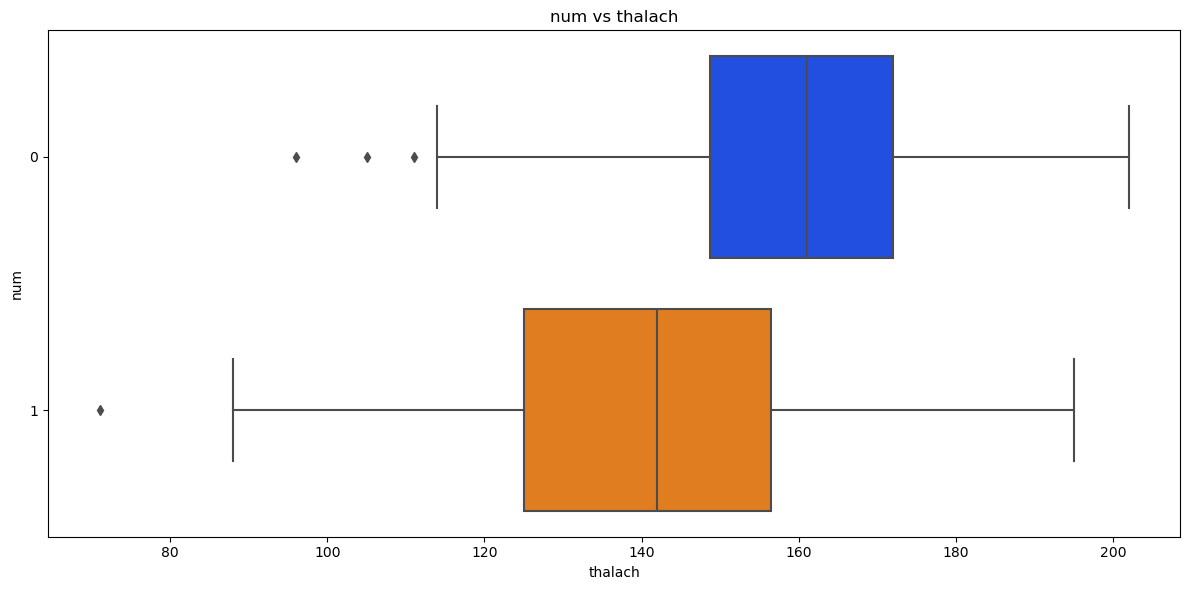


=== OLDPEAK ===


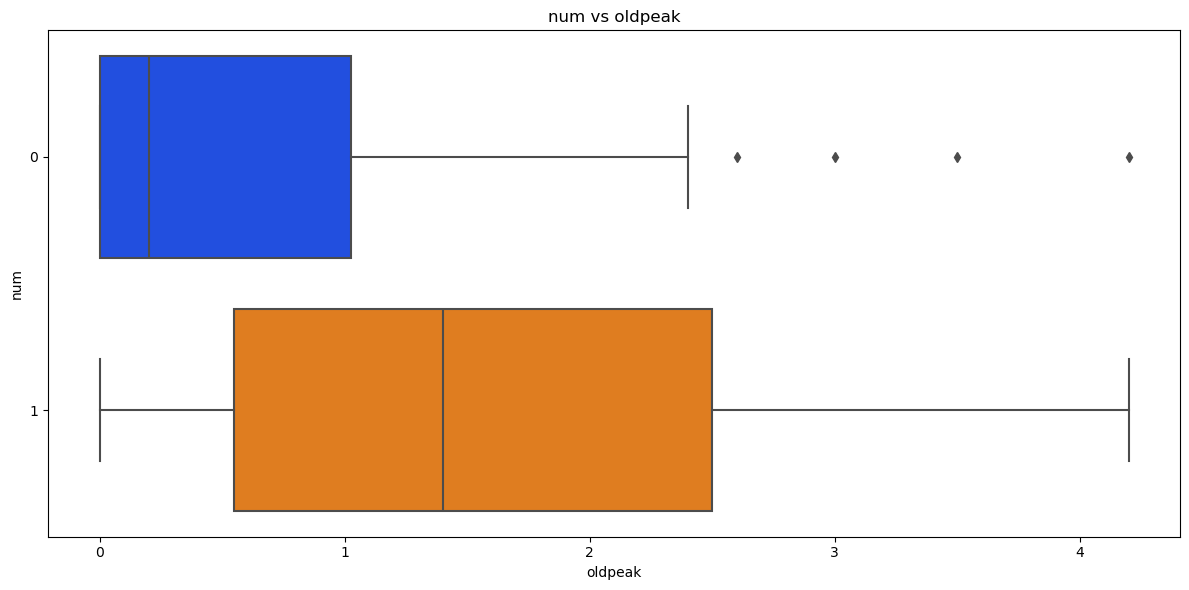

In [28]:
for col in numericas:
    print(f"\n=== {col.upper()} ===")
    plt.figure(figsize=(12, 6))
    sns.boxplot(
        x=col,          
        y='num',        
        data=df, 
        palette='bright', 
        orient='h'      
    )
    plt.title(f'num vs {col}') 
    plt.tight_layout()
    plt.show()

**Interpretación**

1. `age` (Edad)
- **Distribución por grupo:**
  - **Enfermedad (num=1):** Mediana alrededor de 58 años, con rango intercuartílico (IQR) entre ~52-62 años.
  - **No enfermedad (num=0):** Mediana ligeramente menor, alrededor de 52 años, con IQR entre ~45-59 años.
  - **Interpretación:** Los pacientes con enfermedad cardíaca tienden a ser mayores en promedio, pero la superposición es significativa. La edad es un factor de riesgo, pero no un discriminador perfecto.

2. `trestbps` (Presión arterial en reposo)
- **Distribución por grupo:**
  - Ambos grupos tienen medianas muy similares (~130 mm Hg).
  - **Enfermedad (num=1):** Mayor dispersión hacia valores altos (colas más largas), con outliers en el rango de 170-180 mm Hg.
  - **Interpretación:** La presión arterial no diferencia claramente entre grupos en su mediana, pero la presencia de valores extremos altos en el grupo con enfermedad sugiere que la hipertensión severa puede ser un factor de riesgo.

3. `chol` (Colesterol sérico)
- **Distribución por grupo:**
  - **Enfermedad (num=1):** Mediana ligeramente más alta (~249 mg/dl) comparado a no enfermedad (~230 mg/dl).
  - **No enfermedad (num=0):** Menor dispersión y menos outliers.
  - **Enfermedad (num=1):** Presencia de outliers significativos por encima de 350 mg/dl.
  - **Interpretación:** El colesterol elevado está asociado con enfermedad cardíaca, especialmente en valores extremos (outliers). La superposición es alta, pero los niveles muy altos son predictores importantes.

4. `thalach` (Frecuencia cardíaca máxima)
- **Distribución por grupo:**
  - **Enfermedad (num=1):** Mediana más baja (~145-150 lpm).
  - **No enfermedad (num=0):** Mediana más alta (~160-165 lpm).
  - **Interpretación:** Los pacientes sin enfermedad alcanzan frecuencias cardíacas más altas durante el ejercicio, lo que sugiere mejor capacidad cardiovascular. Una menor frecuencia cardíaca máxima es un fuerte predictor de enfermedad cardíaca.

5. `oldpeak` (Depresión del segmento ST)
- **Distribución por grupo:**
  - **No enfermedad (num=0):** Mediana cercana a 0, con IQR muy estrecho (0-1).
  - **Enfermedad (num=1):** Mediana más alta (~1.5), con IQR amplio (0.8-2.5).
  - **Interpretación:** La depresión del segmento ST es uno de los predictores más fuertes. Los pacientes con enfermedad tienen valores significativamente más altos, indicando isquemia inducible durante el ejercicio.


- **Predictores fuertes:** `thalach` (frecuencia cardíaca máxima) y `oldpeak` (depresión del ST) muestran diferencias claras entre grupos y son los discriminadores más potentes.
- **Predictores moderados:** `age` y `chol` tienen diferencias sutiles pero consistentes.
- **Predictor débil:** `trestbps` (presión arterial) muestra superposición casi completa, con valor predictivo limitado en este análisis bivariado.
- **Outliers:** Variables como `chol` y `oldpeak` tienen outliers clínicamente relevantes en el grupo con enfermedad, lo que refuerza su importancia.

Para comprender la distribución y la solapación de cada variable numérica entre los pacientes sanos y aquellos con diagnóstico positivo, se generaron histogramas comparativos. Estos gráficos permiten visualizar diferencias en la forma de la distribución, tendencias centrales y dispersión entre las dos clases, lo que ayuda a identificar qué variables tienen un mayor poder discriminatorio.


=== AGE ===


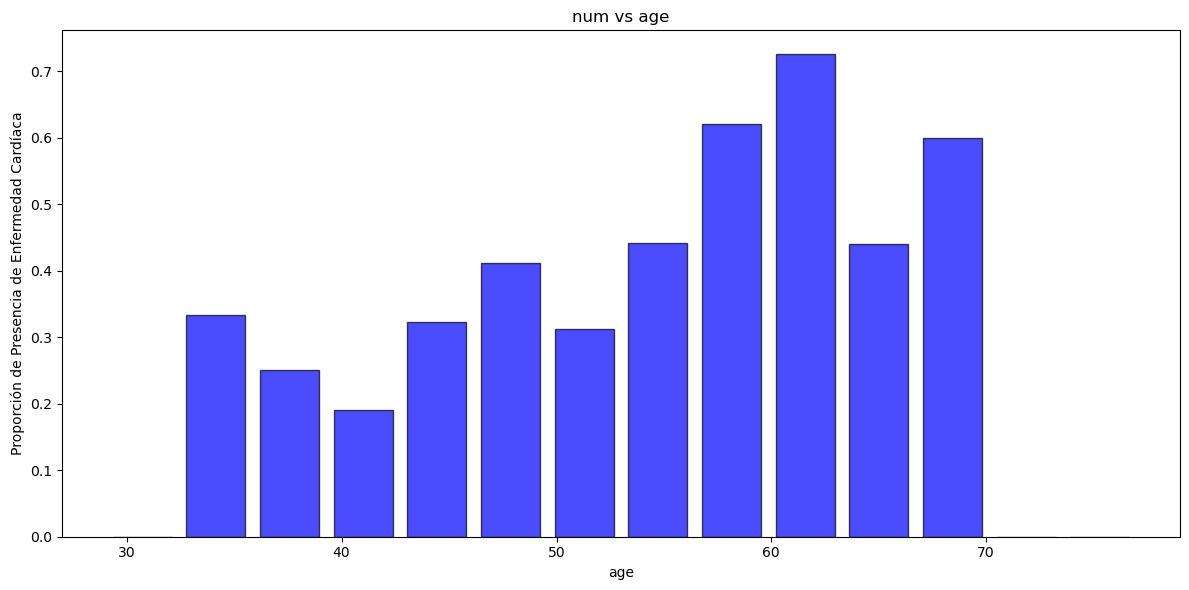


=== TRESTBPS ===


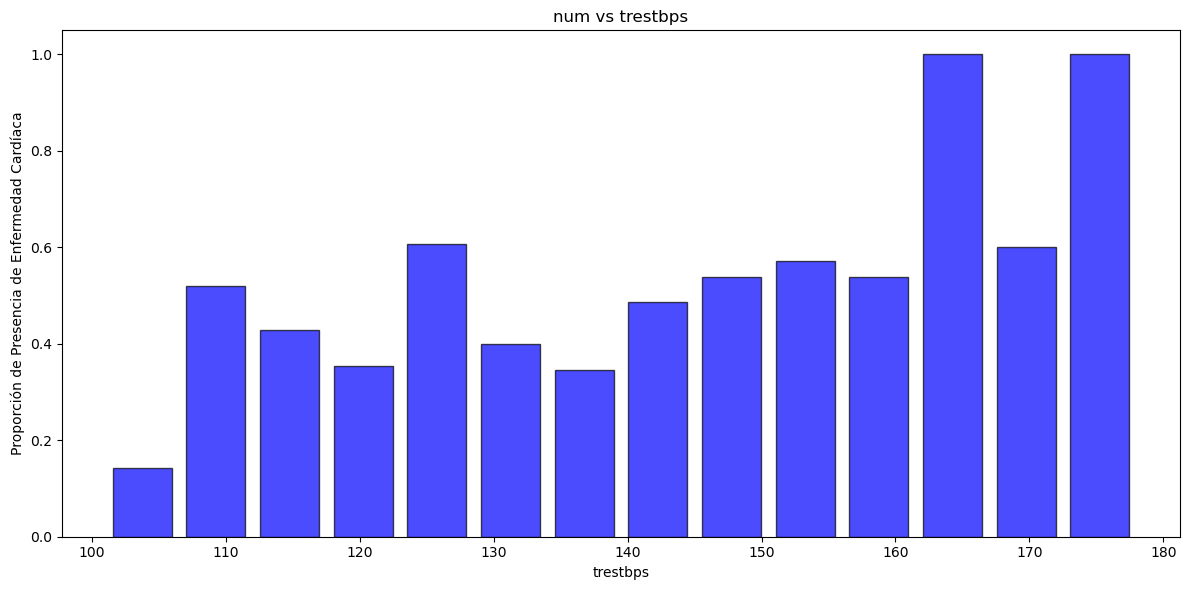


=== CHOL ===


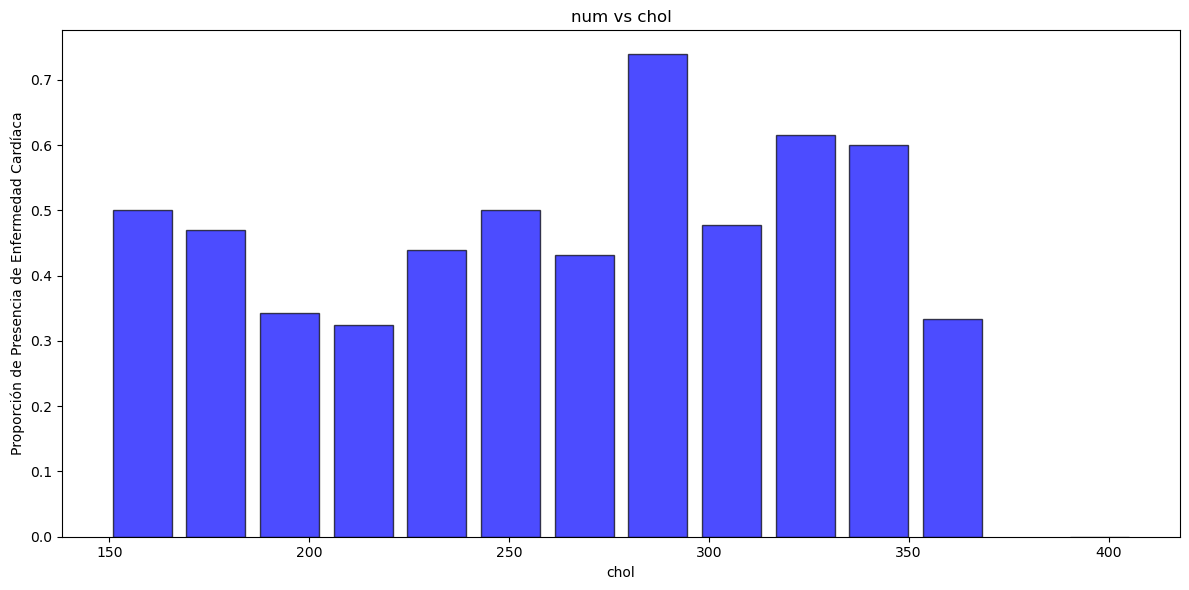


=== THALACH ===


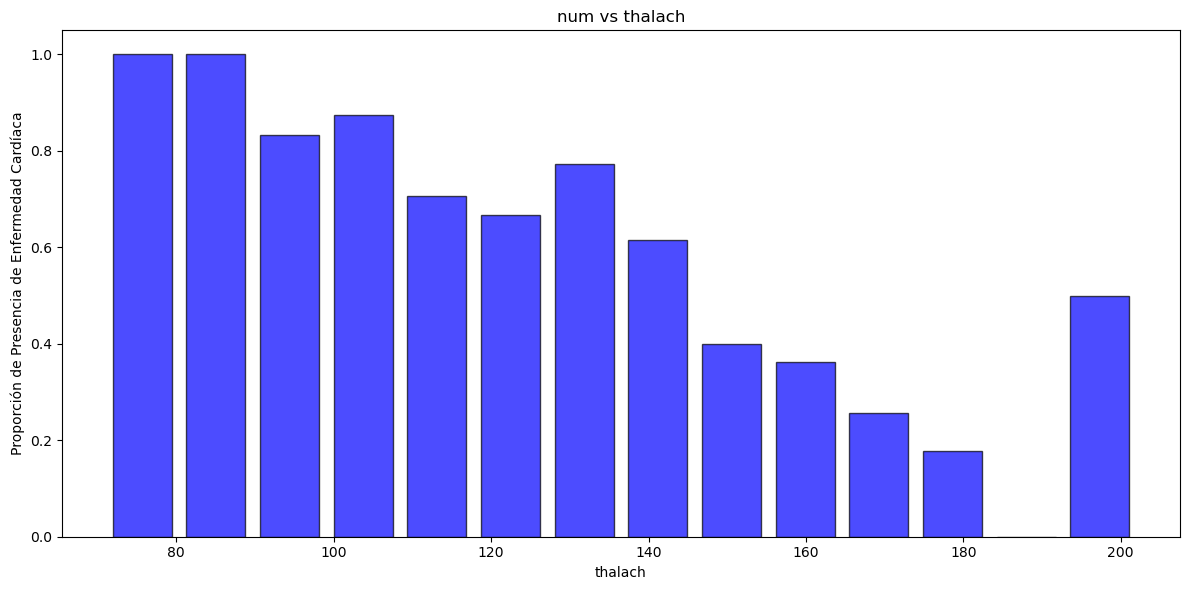


=== OLDPEAK ===


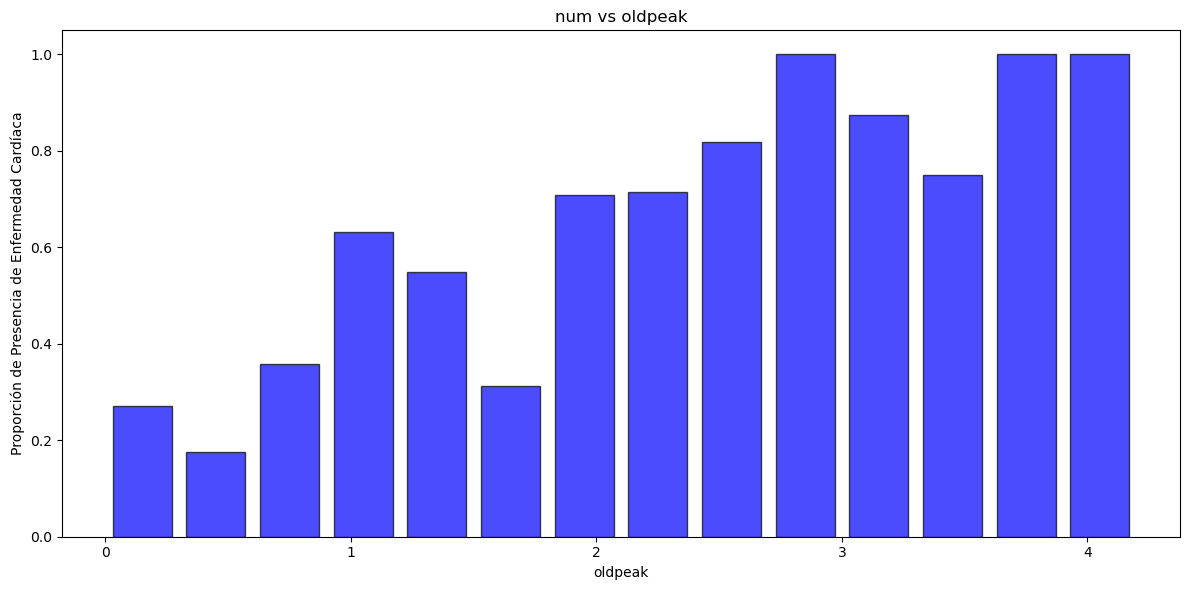

In [29]:
for col in numericas:
    
    print(f"\n=== {col.upper()} ===")
    plt.figure(figsize=(12, 6))
    
    bins = np.linspace(df[col].min(), df[col].max(), 15)  
    
    bin_centers = []
    proportions = []
    
    for i in range(len(bins)-1):
        bin_data = df[(df[col] >= bins[i]) & (df[col] < bins[i+1])]
        if len(bin_data) > 0:
            proportion = bin_data['num'].mean()  
            bin_center = (bins[i] + bins[i+1]) / 2
            bin_centers.append(bin_center)
            proportions.append(proportion)
    
    plt.bar(bin_centers, proportions, width=(bins[1]-bins[0])*0.8, 
            alpha=0.7, color='blue', edgecolor='black')
    
    plt.title(f'num vs {col}')
    plt.xlabel(col)
    plt.ylabel('Proporción de Presencia de Enfermedad Cardíaca')
    plt.tight_layout()
    plt.show()

## **Análisis Multivariado**

Para identificar relaciones lineales entre las variables del Dataset, se generó una matriz de correlación mediante un heatmap. Este gráfico muestra el coeficiente de correlación de Pearson (rango: -1 a 1) entre cada par de variables, utilizando una escala de colores (azul para correlaciones negativas, rojo para positivas). Los valores numéricos anotados permiten evaluar posibles dependencias entre variables.

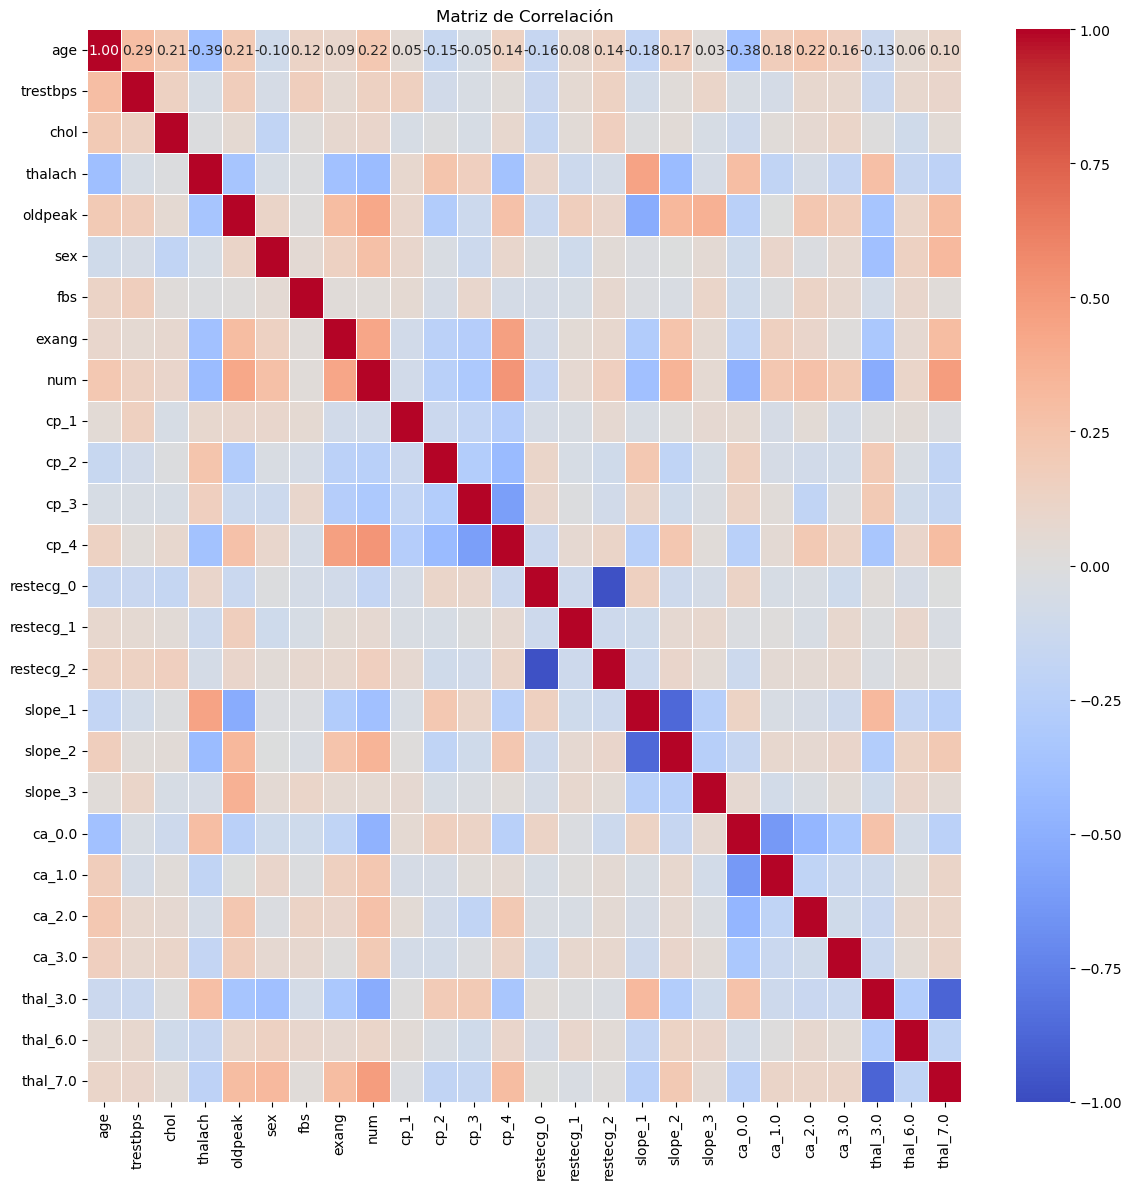

In [30]:
encoder = OneHotEncoder(handle_unknown="ignore")
encoded = encoder.fit_transform(df[categoricas])

encoded_df = pd.DataFrame(
    encoded.toarray(),
    columns=encoder.get_feature_names_out(categoricas),
    index=df.index
)

df_encoded = pd.concat([df[numericas + binarias], encoded_df], axis=1)

plt.figure(figsize=(12, 12))
sns.heatmap(
    df_encoded.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    linewidths=0.5
)
plt.title("Matriz de Correlación")
plt.tight_layout()
plt.show()



## **Multicolinealidad**

los clasificadores bayesianos (GaussianNB, BernoulliNB, MultinomialNB) no requieren tratamiento de multicolinealidad debido a su estructura algorítmica fundamental:
- **Supuesto de independencia condicional**: Los modelos Naive Bayes asumen que las variables predictoras son independientes entre sí dada la variable objetivo, por lo que la multicolinealidad no viola sus supuestos teóricos.
- **Estimación por separado**: Cada variable se evalúa independientemente en términos de su relación con la variable respuesta, sin calcular intercorrelaciones entre predictores.
- **Robustez estructural**: La estimación de probabilidades condicionales es menos sensible a las correlaciones entre variables predictoras.

In [31]:
binarias.remove("num")
y = df["num"]
X = df.drop(columns=["num"])

## **Creación del Conjunto de Entrenamiento y Prueba**

Para evaluar de manera rigurosa y justa el desempeño final del modelo optimizado, es esencial probarlo en datos que no hayan sido vistos durante el proceso de ajuste de hiperparámetro. Por esta razón, se divide el dataset en subconjuntos de entrenamiento y prueba. El conjunto de entrenamiento (`X_train`, `y_train`) se utilizará para reentrenar el mejor modelo con todos los datos disponibles de entrenamiento, mientras que el conjunto de prueba (`X_test`, `y_test`) se reservará exclusivamente para la evaluación final, proporcionando una estimación no sesgada del rendimiento del modelo en datos nuevos.

Se divide las features (`X`) y la variable objetivo binaria (`y`), utilizando el parámetro `stratify` para garantizar que la proporción de las clases `num` se mantenga igual en ambos conjuntos, preservando así el balance original.

Un 20% de los datos se asigna para prueba en ambos casos, utilizando una semilla (`random_state=42`) para asegurar la reproducibilidad de la partición.

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

## **Construcción del Preprocesador Central con ColumnTransformer**

Para optimizar el desempeño de cada algoritmo, se implementaron estrategias de preprocesamiento diferenciadas que cumplen con los supuestos teóricos de cada clasificador:

- **Para GaussianNB y Regresión Logística:** Se aplicó estandarización (`StandardScaler`) a las variables numéricas para satisfacer el supuesto de normalidad y facilitar la convergencia, junto con codificación one-hot para variables categóricas, eliminando la primera categoría para evitar multicolinealidad.

- **Para BernoulliNB y MultinomialNB:** Dado que estos modelos requieren datos discretos, se transformaron las variables numéricas mediante discretización en 5 bins por cuantiles (`KBinsDiscretizer`), preservando el orden natural de los datos mediante codificación ordinal, junto con one-hot encoding para las variables categóricas.

Todos los preprocessadores fueron configurados con `handle_unknown='ignore'` para garantizar robustez ante categorías no vistas durante el entrenamiento, y `remainder='passthrough'` para asegurar la integridad de todas las variables en el pipeline.

In [33]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numericas),  
        ('cat', OneHotEncoder(drop="first", handle_unknown='ignore'), categoricas),  
        ('bin', 'passthrough', binarias)]
)

preprocessor_bnb = ColumnTransformer(
    transformers=[
        ('num', KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile'), numericas),  
        ('cat', OneHotEncoder(drop="first", handle_unknown='ignore'), categoricas), 
        ('bin', 'passthrough', binarias)]
)

preprocessor_mnb = ColumnTransformer(
    transformers=[
        ('num', KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile'), numericas),  
        ('cat', OneHotEncoder(drop="first", handle_unknown='ignore'), categoricas),
        ('bin', 'passthrough', binarias)]
)

preprocessor_logreg = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numericas),
        ('cat', OneHotEncoder(drop="first", handle_unknown='ignore'), categoricas),
        ('bin', 'passthrough', binarias)]
)


## **Construcción de Pipelines**

Para cumplir con el objetivo de integrar un flujo completo de machine learning, se construyen pipelines independientes. Un pipeline encapsula de manera secuencial y automatizada todas las etapas del proceso de modelado, desde el preprocesamiento de los datos hasta la ejecución del algoritmo de aprendizaje. Esto garantiza que cada transformación se aplique de manera consistente durante el entrenamiento y la predicción, eliminando el riesgo de data leakage y asegurando la reproducibilidad de los resultados.

Cada pipeline se compone de dos etapas fundamentales:

1. `preprocessor`: La transformación de características definida previamente en el ColumnTransformer, que se encarga de escalar las variables numéricas y codificar las categóricas.

2. `classifier`: El estimador o algoritmo de machine learning que aprenderá a predecir las características transformadas.

In [34]:
pipeline_gnb = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("classifier", GaussianNB())
])

pipeline_bnb = Pipeline(steps=[
    ("preprocessing", preprocessor_bnb),
    ("classifier", BernoulliNB())
])

pipeline_mnb = Pipeline(steps=[
    ("preprocessing", preprocessor_mnb),
    ("classifier", MultinomialNB())
])


C = [0.01, 0.1, 1, 10, 100]

pipeline_logreg_cv = Pipeline(steps=[
    ("preprocessing", preprocessor_logreg),
    ("classifier", LogisticRegressionCV(Cs=C,
                                        cv=5,
                                        penalty="l2",
                                        solver="liblinear",
                                        max_iter=1000,
                                        n_jobs=-1,
                                        scoring="roc_auc"))
])


## **Evaluación del Desempeño Predictivo**

Para comparar de manera robusta la capacidad discriminativa de los diferentes clasificadores, se realizó una evaluación mediante validación cruzada de 5 folds utilizando el área bajo la curva ROC (ROC-AUC) como métrica principal. Esta métrica es particularmente adecuada para problemas de clasificación binaria ya que evalúa la capacidad del modelo para distinguir entre clases across todos los posibles umbrales de decisión, siendo menos sensible al desbalance de clases que el accuracy. Cada modelo fue evaluado con su pipeline de preprocesamiento correspondiente, garantizando que las transformaciones se aplicaran consistentemente en cada fold de la validación.

In [35]:
scores_gnb = cross_val_score(pipeline_gnb, X_train, y_train, cv=5, scoring='roc_auc')
print("GaussianNB - AUC medio:", scores_gnb.mean())

scores_bnb = cross_val_score(pipeline_bnb, X_train, y_train, cv=5, scoring='roc_auc')
print("BernoulliNB - AUC medio:", scores_bnb.mean())

scores_mnb = cross_val_score(pipeline_mnb, X_train, y_train, cv=5, scoring='roc_auc')
print("MultinomialNB - AUC medio:", scores_mnb.mean())

GaussianNB - AUC medio: 0.8745475941128115
BernoulliNB - AUC medio: 0.8843997387475648
MultinomialNB - AUC medio: 0.8636352375482812


**Interpretación**

1. **BernoulliNB - AUC: 0.884**
    - **Desempeño muy bueno** - Mejor modelo.
    - **Interpretación:** A pesar de su simplicidad, el modelo BernoulliNB muestra gran poder discriminativo.
    - **Implicación:** La discretización de variables funcionó bien para capturar relaciones no lineales.

2. **GaussianNB - AUC: 0.874**
    - **Desempeño bueno** - Segundo lugar.
    - **Interpretación:** Buen desempeño considerando que asume normalidad en todas las variables.
    - **Implicación:** Las variables numéricas probablemente se aproximan bien a distribuciones normales.

4. **MultinomialNB - AUC: 0.863**
    - **Desempeño aceptable** - Tercer lugar.
    - **Interpretación:** Menor capacidad discriminativa comparado a los otros modelos.
    - **Implicación:** La discretización en bins puede haber perdido información importante para este modelo específico.

- **Todos los modelos tienen buen desempeño** (AUC > 0.86), indicando que las features son predictivas.
- **BernoulliNB sorprende positivamente** - supera a GaussianNB a pesar de su simplicidad.
- **La diferencia entre modelos es pequeña** sugiriendo que todos capturan patrones similares.


In [36]:
pipeline_gnb.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalach', 'oldpeak']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['cp', 'restecg', 'slope',
                                                   'ca', 'thal']),
                                                 ('bin', 'passthrough',
                                                  ['sex', 'fbs', 'exang'])])),
                ('classifier', GaussianNB())])

In [37]:
pipeline_bnb.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  KBinsDiscretizer(encode='ordinal'),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalach', 'oldpeak']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['cp', 'restecg', 'slope',
                                                   'ca', 'thal']),
                                                 ('bin', 'passthrough',
                                                  ['sex', 'fbs', 'exang'])])),
                ('classifier', BernoulliNB())])

In [38]:
pipeline_mnb.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  KBinsDiscretizer(encode='ordinal'),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalach', 'oldpeak']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['cp', 'restecg', 'slope',
                                                   'ca', 'thal']),
                                                 ('bin', 'passthrough',
                                                  ['sex', 'fbs', 'exang'])])),
                ('classifier', MultinomialNB())])

## **Evaluación del Modelo de Clasificación en el Conjunto de Prueba (Modelo GaussianNB)**

Para completar el análisis del objetivo de clasificación binaria, se evaluó el desempeño del modelo GaussianNB en el conjunto de prueba reservado para esta tarea. La evaluación de un modelo de clasificación requiere un análisis más multidimensional que la regresión, ya que es necesario considerar no solo la capacidad de predicción general (accuracy) sino también el equilibrio entre los diferentes tipos de error (falsos positivos y falsos negativos), lo cual es crucial dependiendo del contexto de aplicación.

El modelo se reentrenó con la totalidad del conjunto de entrenamiento de clasificación (`X_train`, `y_train`) y se generaron tanto predicciones de clase (`predict`) como probabilidades (`predict_proba`) para el conjunto de prueba. El desempeño se evaluó mediante un conjunto exhaustivo de métricas y visualizaciones:

- **Métricas de Evaluación**:

    - **Accuracy**: Proporción general de predicciones correctas.

    - **Precision**: Capacidad del modelo de evitar falsos positivos.

    - **Recall**: Capacidad del modelo de evitar falsos negativos.

    - **F1-score**: Media armónica entre Precision y Recall, ideal para conjuntos balanceados.

- **Visualizaciones**:

    - **Matriz de Confusión**: Muestra de forma explícita los aciertos (diagonal) y los errores (falsos positivos y falsos negativos) del modelo.

    - **Curva ROC y AUC**: Evalúa la capacidad del modelo para distinguir entre clases a través de todos los posibles umbrales de clasificación. Un AUC de 0.5 representa un modelo aleatorio, mientras que 1.0 representa una separación perfecta.

Evaluación GaussianNB
Accuracy: 0.639344262295082
Precision: 0.5681818181818182
Recall: 0.8928571428571429
F1-score: 0.6944444444444444


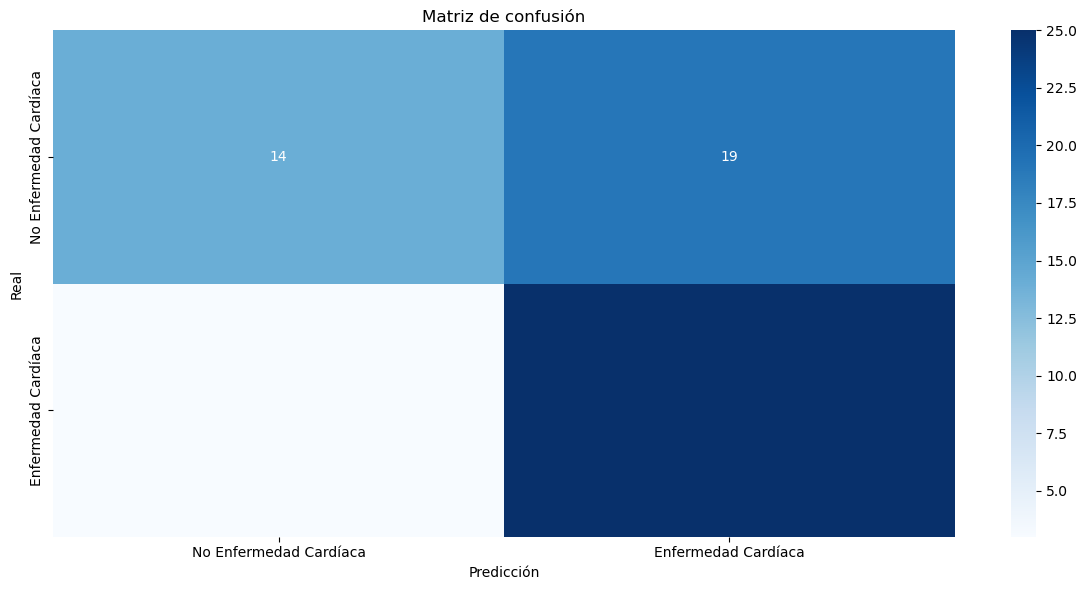

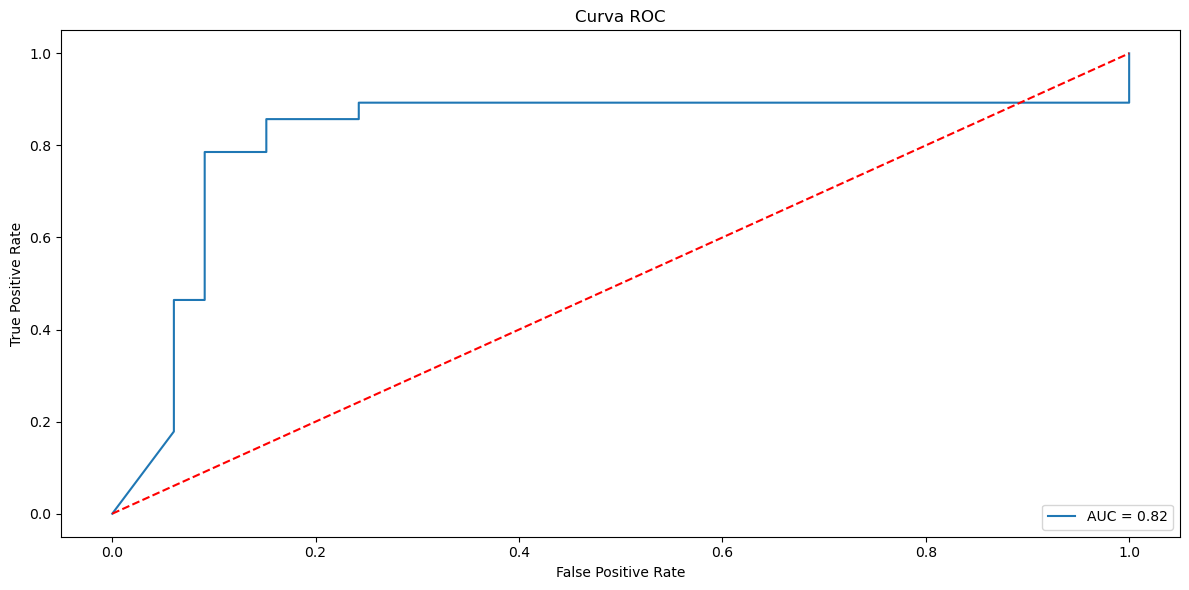

In [39]:
y_pred = pipeline_gnb.predict(X_test)
y_pred_proba = pipeline_gnb.predict_proba(X_test)[:,1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Evaluación GaussianNB")
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1-score:", f1)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Enfermedad Cardíaca","Enfermedad Cardíaca"], 
            yticklabels=["No Enfermedad Cardíaca","Enfermedad Cardíaca"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión")
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(12, 6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Interpretación**

1. `Accuracy (63.9%)`:
    - **Interpretación:** El modelo clasifica correctamente el **63.9%** de todas las instancias.
    - **Evaluación:** Valor moderado pero bajo para un problema médico. Sugiere que el modelo tiene margen de mejora.

2. `Recall (89.3%)`:
    - **Interpretación:** El modelo identifica correctamente el **89.3%** de todos los casos **reales de enfermedad cardíaca**.
    - **Evaluación:** Excelente sensibilidad. Captura casi todos los pacientes enfermos.
    - **Implicación clínica:** Muy bueno para **detección temprana**, pocos falsos negativos.

3. `Precision (56.8%)`:
    - **Interpretación:** Solo el **56.8%** de las predicciones como "enfermo" son correctas.
    - **Evaluación:** Baja precisión. Muchos falsos positivos.
    - **Implicación clínica:** Podría generar **alarmas falsas** y costos innecesarios en diagnósticos.

4. `F1-score (69.4%)`:
    - **Interpretación:** Punto medio entre Precision y Recall.
    - **Evaluación:** Moderado. Refleja el trade-off entre los dos aspectos.

### **Análisis de Calibración y Distribución de Probabilidades del Modelo GaussianNB**

Para evaluar la confiabilidad de las predicciones probabilísticas del modelo GaussianNB, se generaron dos visualizaciones críticas: un histograma de distribución de probabilidades y una curva de calibración. El histograma permite comparar la densidad de las probabilidades predichas para cada clase real, revelando si el modelo distingue efectivamente entre pacientes sanos y enfermos. La curva de calibración evalúa cómo se alinean las probabilidades predichas con las frecuencias observadas empíricamente, indicando si las probabilidades son confiables para la toma de decisiones clínicas (ej: si una probabilidad predicha del 80% corresponde efectivamente a un 80% de casos reales de enfermedad).

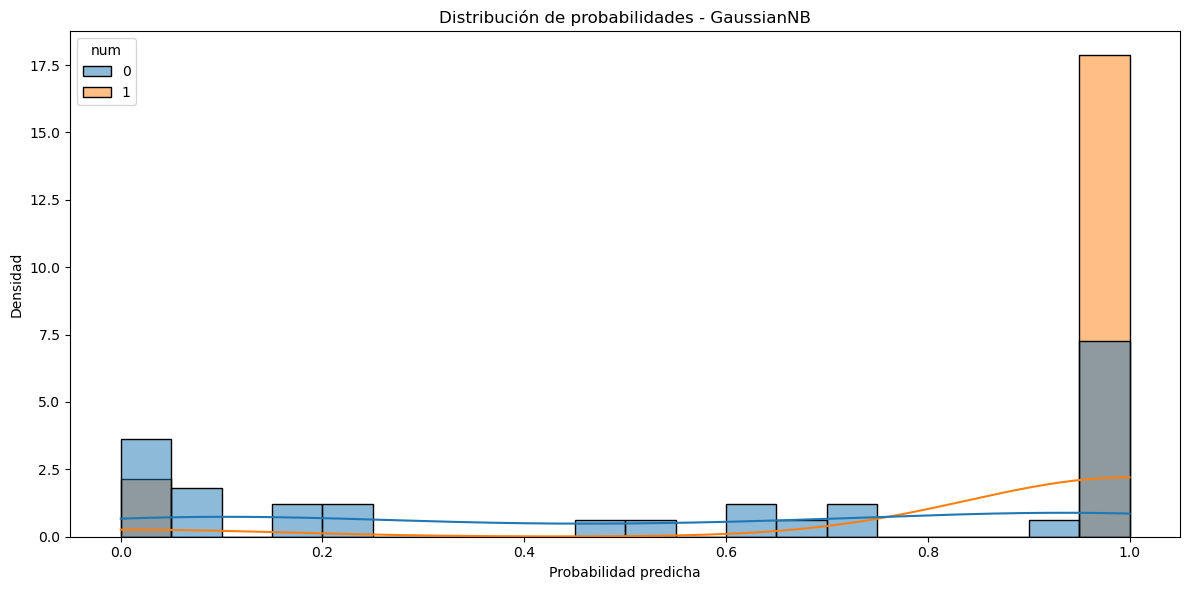

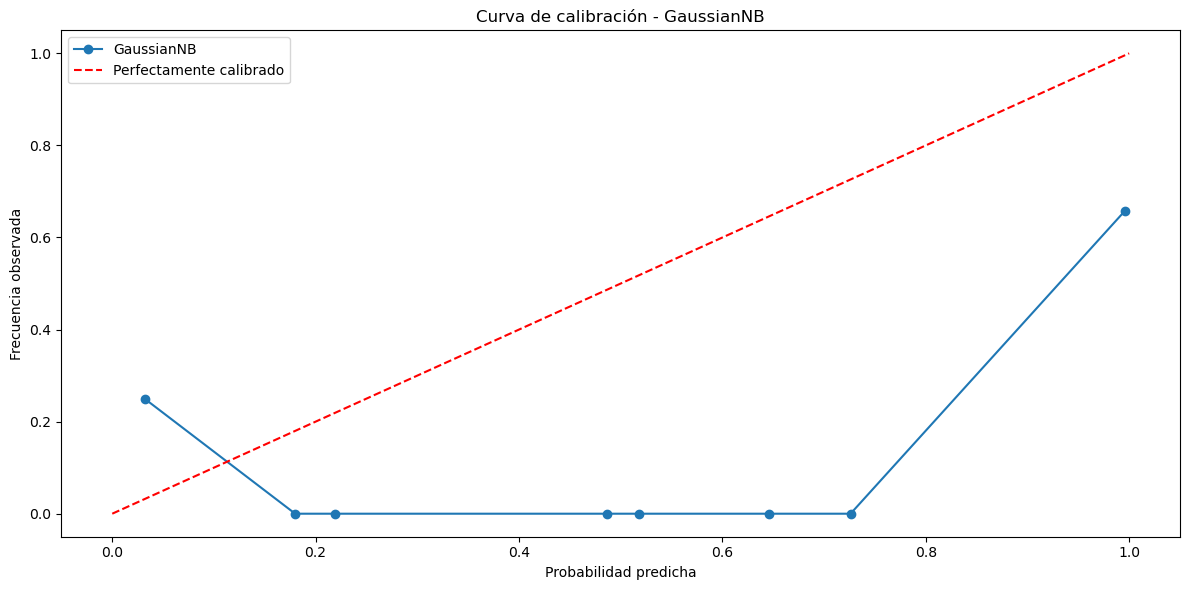

In [40]:
# Histograma de probabilidades
plt.figure(figsize=(12,6))
sns.histplot(x=y_pred_proba, hue=y_test, bins=20, kde=True, stat="density", common_norm=False)
plt.title("Distribución de probabilidades - GaussianNB")
plt.xlabel("Probabilidad predicha")
plt.ylabel("Densidad")
plt.tight_layout()
plt.show()

# Curva de calibración
prob_true, prob_pred = calibration_curve(y_test, y_pred_proba, n_bins=10)

plt.figure(figsize=(12,6))
plt.plot(prob_pred, prob_true, marker='o', label="GaussianNB")
plt.plot([0,1],[0,1],"r--", label="Perfectamente calibrado")
plt.title("Curva de calibración - GaussianNB")
plt.xlabel("Probabilidad predicha")
plt.ylabel("Frecuencia observada")
plt.legend()
plt.tight_layout()
plt.show()


## **Evaluación del Modelo de Clasificación en el Conjunto de Prueba (Modelo BernoulliNB)**

Para completar el análisis del objetivo de clasificación binaria, se evaluó el desempeño del modelo BernoulliNB en el conjunto de prueba reservado para esta tarea. La evaluación de un modelo de clasificación requiere un análisis más multidimensional que la regresión, ya que es necesario considerar no solo la capacidad de predicción general (accuracy) sino también el equilibrio entre los diferentes tipos de error (falsos positivos y falsos negativos), lo cual es crucial dependiendo del contexto de aplicación.

El modelo se reentrenó con la totalidad del conjunto de entrenamiento de clasificación (`X_train`, `y_train`) y se generaron tanto predicciones de clase (`predict`) como probabilidades (`predict_proba`) para el conjunto de prueba. El desempeño se evaluó mediante un conjunto exhaustivo de métricas y visualizaciones:

- **Métricas de Evaluación**:

    - **Accuracy**: Proporción general de predicciones correctas.

    - **Precision**: Capacidad del modelo de evitar falsos positivos.

    - **Recall**: Capacidad del modelo de evitar falsos negativos.

    - **F1-score**: Media armónica entre Precision y Recall, ideal para conjuntos balanceados.

- **Visualizaciones**:

    - **Matriz de Confusión**: Muestra de forma explícita los aciertos (diagonal) y los errores (falsos positivos y falsos negativos) del modelo.

    - **Curva ROC y AUC**: Evalúa la capacidad del modelo para distinguir entre clases a través de todos los posibles umbrales de clasificación. Un AUC de 0.5 representa un modelo aleatorio, mientras que 1.0 representa una separación perfecta.

Evaluación BernoulliNB
Accuracy: 0.9180327868852459
Precision: 0.896551724137931
Recall: 0.9285714285714286
F1-score: 0.9122807017543859


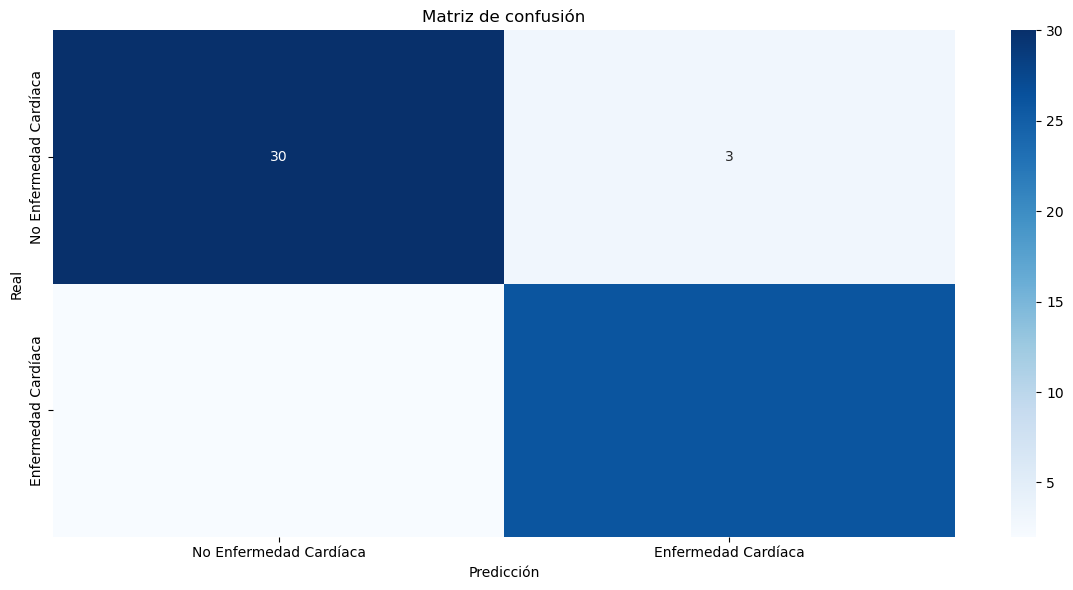

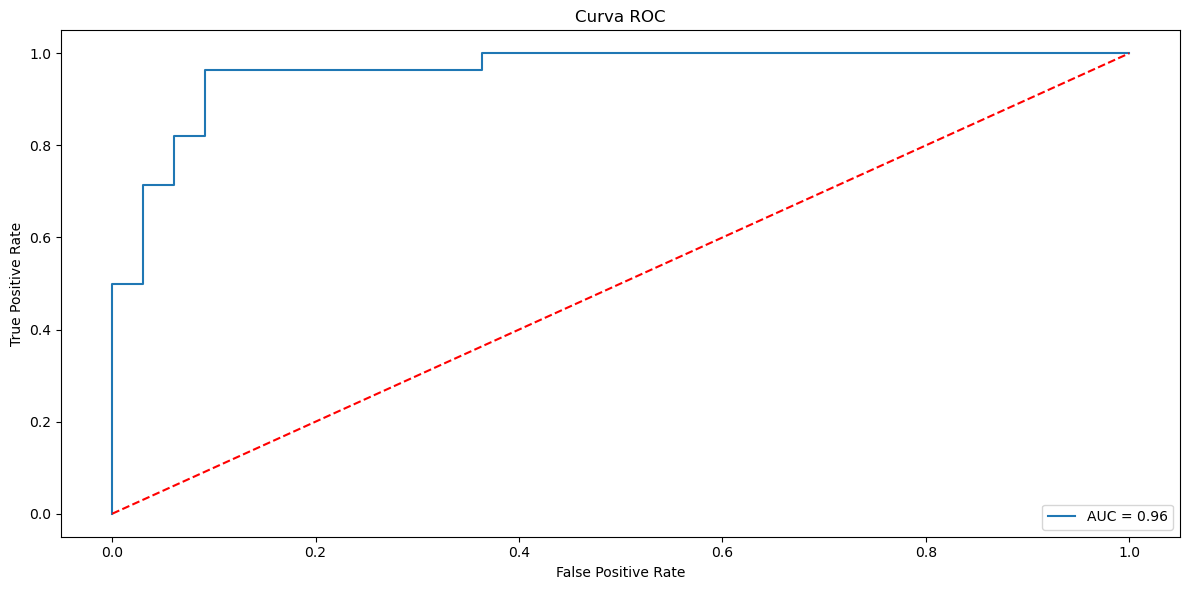

In [41]:
y_pred = pipeline_bnb.predict(X_test)
y_pred_proba = pipeline_bnb.predict_proba(X_test)[:,1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Evaluación BernoulliNB")
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1-score:", f1)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Enfermedad Cardíaca","Enfermedad Cardíaca"], 
            yticklabels=["No Enfermedad Cardíaca","Enfermedad Cardíaca"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión")
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(12, 6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Interpretación**

1. `Accuracy (91.8%)`:
    - **Interpretación:** El modelo clasifica correctamente el **91.8%** de todas las instancias.
    - **Evaluación:** **Excelente**- Muestra alto poder predictivo.

2. `Recall (92.9%)`:
    - **Interpretación:** El modelo identifica correctamente el **92.9%** de todos los casos **reales de enfermedad cardíaca**.
    - **Evaluación:** **Excelente** sensibilidad. Captura casi todos los pacientes enfermos.
    - **Implicación clínica:** Muy pocos falsos negativos - crucial para aplicaciones médicas.

3. `Precision (89.7%)`:
    - **Interpretación:** El **89.7%** de las predicciones como "enfermo" son correctas.
    - **Evaluación:** **Muy alta** - Pocos falsos positivos.
    - **Implicación clínica:** Minimiza diagnósticos innecesarios y costos asociados.

4. `F1-score (91.2%)`:
    - **Interpretación:** Balance perfecto entre Precision y Recall.
    - **Evaluación:** **Excelente** - Indica un modelo bien equilibrado.


**Comparación con GaussianNB:**
- **Accuracy:** 91.8% vs 63.9% (+27.9%)
- **Precision:** 89.7% vs 56.8% (+32.9%)
- **Recall:** 92.9% vs 89.3% (+3.6%)
- **F1-score:** 91.2% vs 69.4% (+21.8%)

**¿Por qué BernoulliNB funciona tan bien?**
1. **Datos discretizados:** Las variables numéricas convertidas a bins se ajustan mejor al modelo.
2. **Naturaleza binaria:** BernoulliNB está diseñado para datos binarios/multinomiales.
3. **Robusto a supuestos:** No requiere normalidad como GaussianNB.


### **Análisis de Calibración y Distribución de Probabilidades del Modelo BernoulliNB**

Para evaluar la confiabilidad de las predicciones probabilísticas del modelo BernoulliNB, se generaron dos visualizaciones críticas: un histograma de distribución de probabilidades y una curva de calibración. El histograma permite comparar la densidad de las probabilidades predichas para cada clase real, revelando si el modelo distingue efectivamente entre pacientes sanos y enfermos. La curva de calibración evalúa cómo se alinean las probabilidades predichas con las frecuencias observadas empíricamente, indicando si las probabilidades son confiables para la toma de decisiones clínicas (ej: si una probabilidad predicha del 80% corresponde efectivamente a un 80% de casos reales de enfermedad).

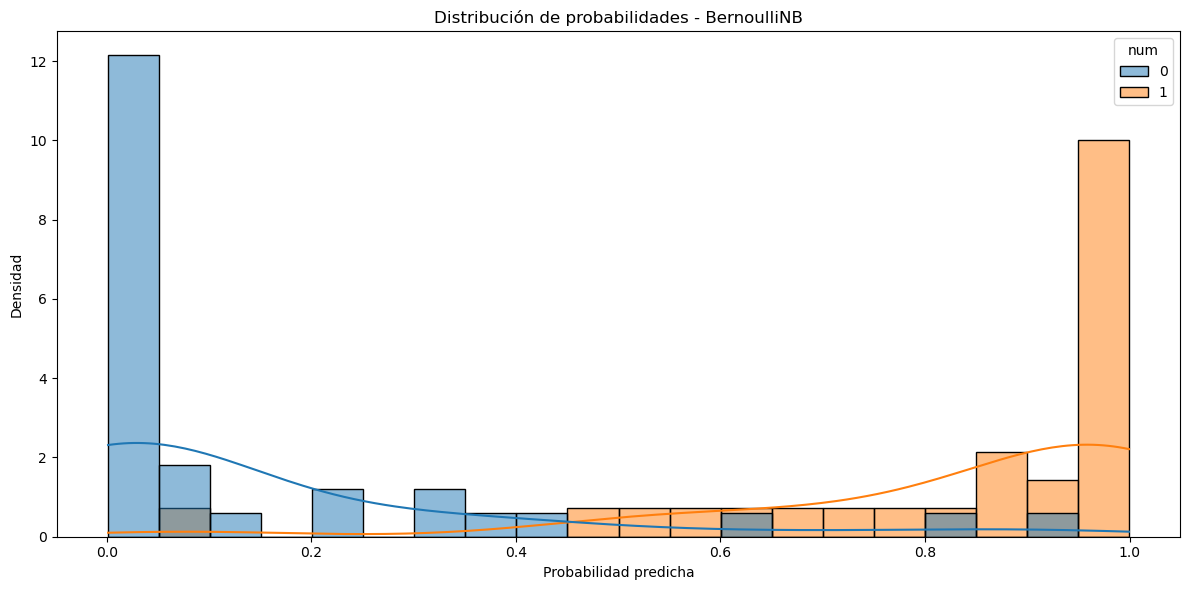

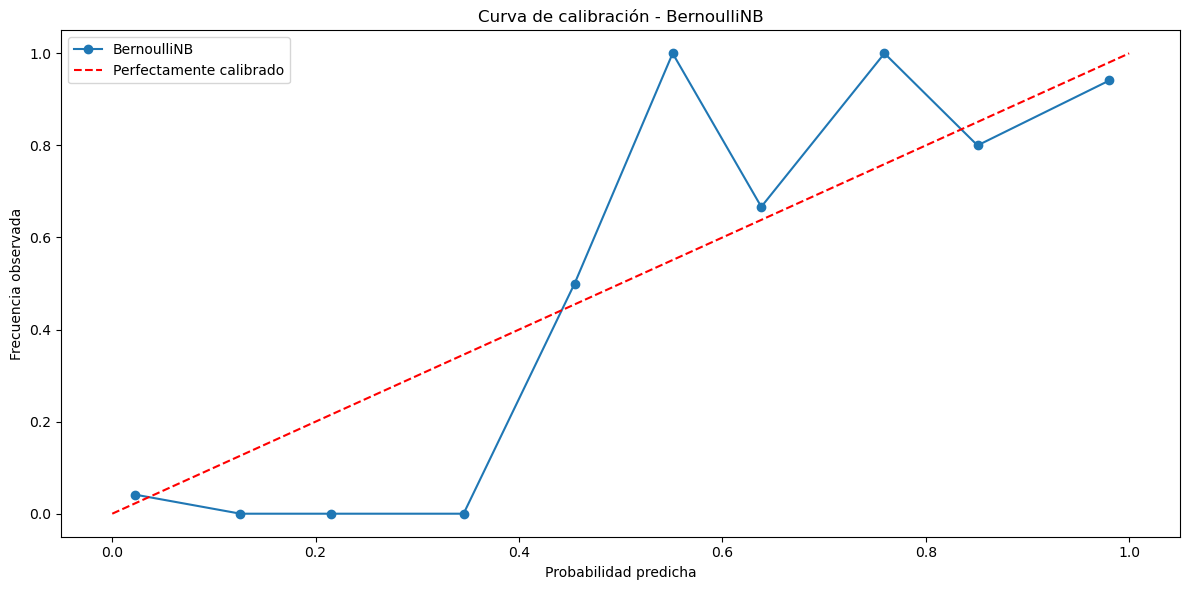

In [42]:
# Histograma de probabilidades
plt.figure(figsize=(12,6))
sns.histplot(x=y_pred_proba, hue=y_test, bins=20, kde=True, stat="density", common_norm=False)
plt.title("Distribución de probabilidades - BernoulliNB")
plt.xlabel("Probabilidad predicha")
plt.ylabel("Densidad")
plt.tight_layout()
plt.show()

# Curva de calibración
prob_true, prob_pred = calibration_curve(y_test, y_pred_proba, n_bins=10)

plt.figure(figsize=(12,6))
plt.plot(prob_pred, prob_true, marker='o', label="BernoulliNB")
plt.plot([0,1],[0,1],"r--", label="Perfectamente calibrado")
plt.title("Curva de calibración - BernoulliNB")
plt.xlabel("Probabilidad predicha")
plt.ylabel("Frecuencia observada")
plt.legend()
plt.tight_layout()
plt.show()


## **Evaluación del Modelo de Clasificación en el Conjunto de Prueba (Modelo MultinomialNB)**

Para completar el análisis del objetivo de clasificación binaria, se evaluó el desempeño del modelo MultinomialNB en el conjunto de prueba reservado para esta tarea. La evaluación de un modelo de clasificación requiere un análisis más multidimensional que la regresión, ya que es necesario considerar no solo la capacidad de predicción general (accuracy) sino también el equilibrio entre los diferentes tipos de error (falsos positivos y falsos negativos), lo cual es crucial dependiendo del contexto de aplicación.

El modelo se reentrenó con la totalidad del conjunto de entrenamiento de clasificación (`X_train`, `y_train`) y se generaron tanto predicciones de clase (`predict`) como probabilidades (`predict_proba`) para el conjunto de prueba. El desempeño se evaluó mediante un conjunto exhaustivo de métricas y visualizaciones:

- **Métricas de Evaluación**:

    - **Accuracy**: Proporción general de predicciones correctas.

    - **Precision**: Capacidad del modelo de evitar falsos positivos.

    - **Recall**: Capacidad del modelo de evitar falsos negativos.

    - **F1-score**: Media armónica entre Precision y Recall, ideal para conjuntos balanceados.

- **Visualizaciones**:

    - **Matriz de Confusión**: Muestra de forma explícita los aciertos (diagonal) y los errores (falsos positivos y falsos negativos) del modelo.

    - **Curva ROC y AUC**: Evalúa la capacidad del modelo para distinguir entre clases a través de todos los posibles umbrales de clasificación. Un AUC de 0.5 representa un modelo aleatorio, mientras que 1.0 representa una separación perfecta.

Evaluación MultinomialNB
Accuracy: 0.8524590163934426
Precision: 0.8275862068965517
Recall: 0.8571428571428571
F1-score: 0.8421052631578947


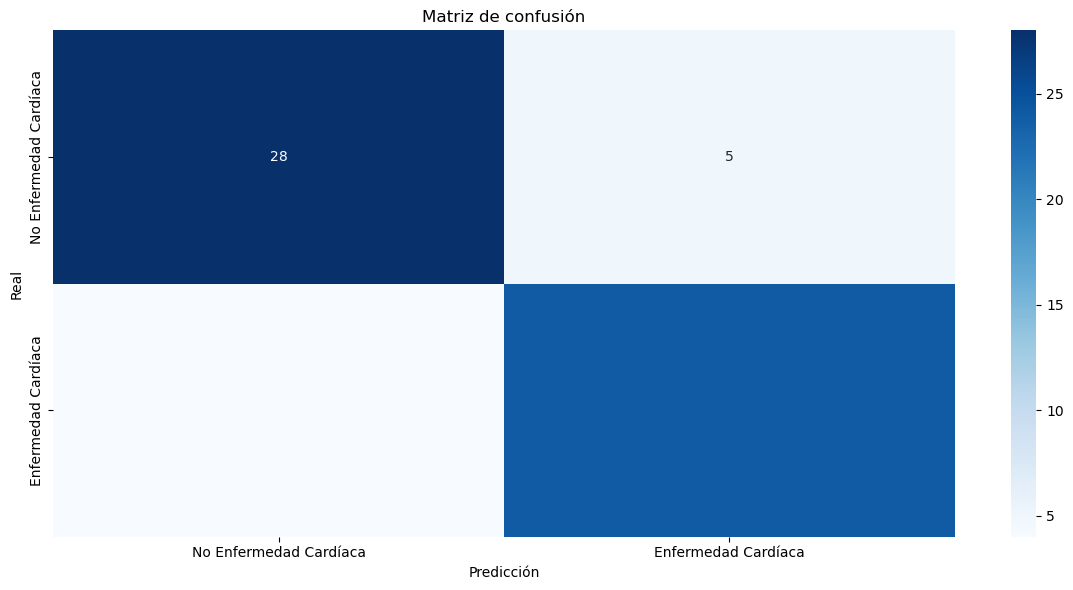

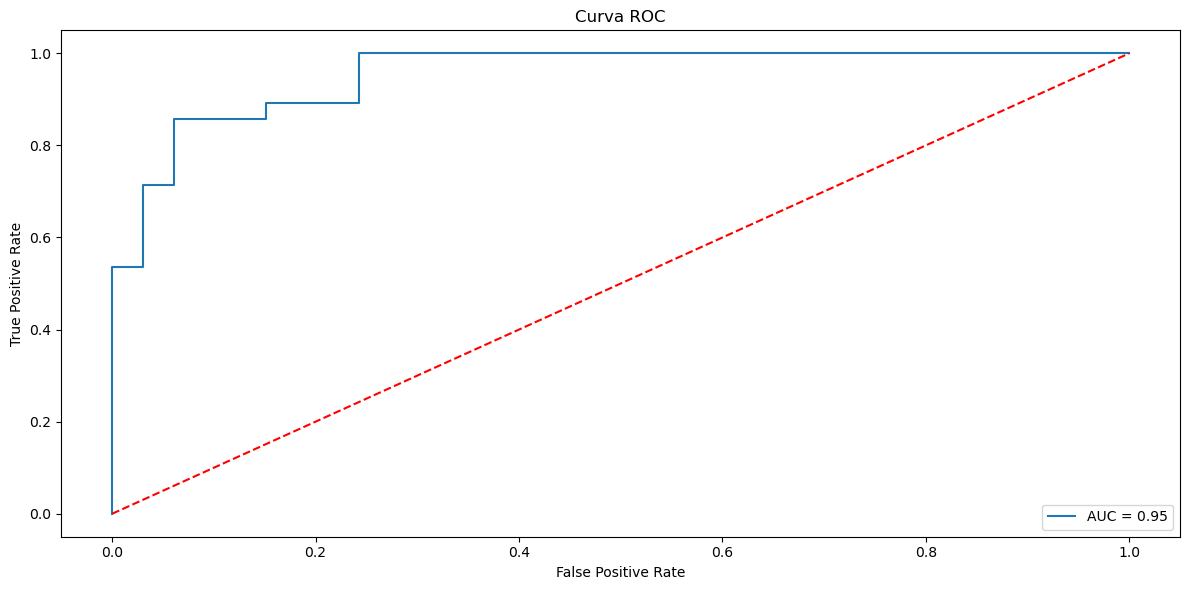

In [43]:
y_pred = pipeline_mnb.predict(X_test)
y_pred_proba = pipeline_mnb.predict_proba(X_test)[:,1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Evaluación MultinomialNB")
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1-score:", f1)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Enfermedad Cardíaca","Enfermedad Cardíaca"], 
            yticklabels=["No Enfermedad Cardíaca","Enfermedad Cardíaca"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión")
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(12, 6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Interpretación**

1. `Accuracy (85.2%)`:
    - **Interpretación:** El modelo clasifica correctamente el **85.2%** de todas las instancias.
    - **Evaluación:** **Muy bueno** - Significativamente mejor que GaussianNB.

2. `Recall (85.7%)`:
    - **Interpretación:** El modelo identifica correctamente el **85.7%** de todos los casos **reales de enfermedad cardíaca**.
    - **Evaluación:** **Muy buena** sensibilidad. Captura la mayoría de pacientes enfermos.
    - **Implicación clínica:** Buen balance en detección de casos positivos.

3. `Precision (82.8%)`:
    - **Interpretación:** El **82.8%** de las predicciones como "enfermo" son correctas.
    - **Evaluación:** **Buena** - Aceptable número de falsos positivos.
    - **Implicación clínica:** Razón aceptable de diagnósticos correctos.

4. `F1-score (84.2%)`:
    - **Interpretación:** Balance muy bueno entre Precision y Recall.
    - **Evaluación:** **Muy bueno** - Indica un modelo bien equilibrado.

**Comparación con otros modelos:**
- **vs GaussianNB (63.9% accuracy):**  **+21.3%** de mejora
- **vs BernoulliNB (91.8% accuracy):**  **-6.6%** de diferencia
- **Balance:** Mejor balance que GaussianNB, ligeramente inferior a BernoulliNB

**Posibles razones del desempeño:**
1. **Naturaleza multinomial:** Funciona mejor con variables discretas que representan conteos o frecuencias.
2. **Discretización adecuada:** Los bins de 5 categorías capturan bien la información.
3. **Robustez:** Menos sensible a outliers que GaussianNB.


### **Análisis de Calibración y Distribución de Probabilidades del Modelo MultinomialNB**

Para evaluar la confiabilidad de las predicciones probabilísticas del modelo MultinomialNB, se generaron dos visualizaciones críticas: un histograma de distribución de probabilidades y una curva de calibración. El histograma permite comparar la densidad de las probabilidades predichas para cada clase real, revelando si el modelo distingue efectivamente entre pacientes sanos y enfermos. La curva de calibración evalúa cómo se alinean las probabilidades predichas con las frecuencias observadas empíricamente, indicando si las probabilidades son confiables para la toma de decisiones clínicas (ej: si una probabilidad predicha del 80% corresponde efectivamente a un 80% de casos reales de enfermedad).

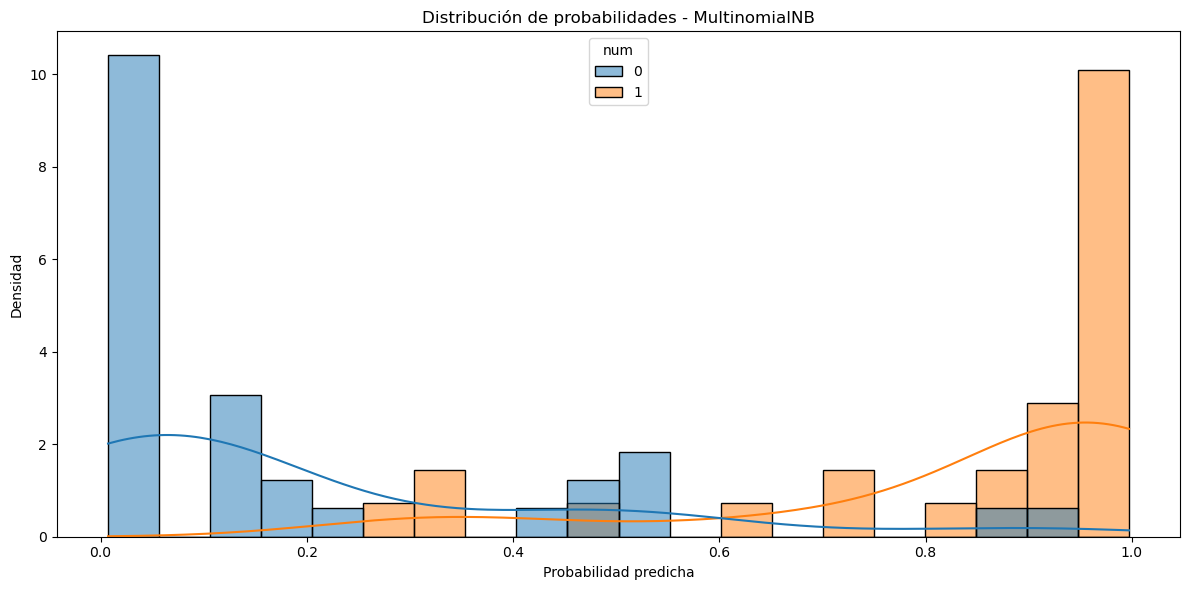

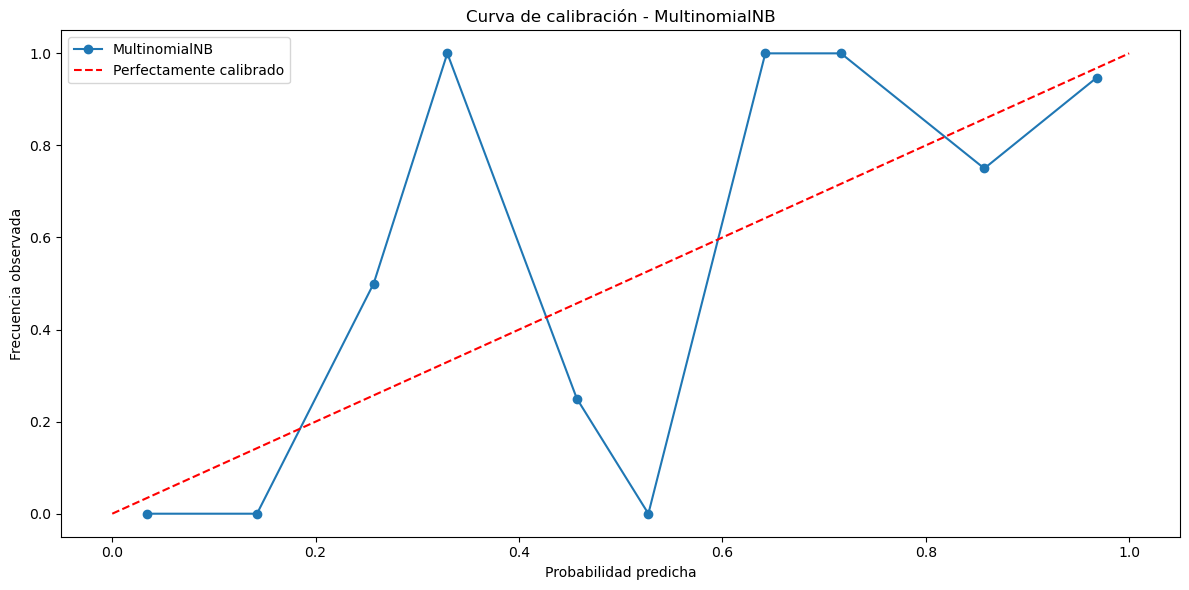

In [44]:
# Histograma de probabilidades
plt.figure(figsize=(12,6))
sns.histplot(x=y_pred_proba, hue=y_test, bins=20, kde=True, stat="density", common_norm=False)
plt.title("Distribución de probabilidades - MultinomialNB")
plt.xlabel("Probabilidad predicha")
plt.ylabel("Densidad")
plt.tight_layout()
plt.show()

# Curva de calibración
prob_true, prob_pred = calibration_curve(y_test, y_pred_proba, n_bins=10)

plt.figure(figsize=(12,6))
plt.plot(prob_pred, prob_true, marker='o', label="MultinomialNB")
plt.plot([0,1],[0,1],"r--", label="Perfectamente calibrado")
plt.title("Curva de calibración - MultinomialNB")
plt.xlabel("Probabilidad predicha")
plt.ylabel("Frecuencia observada")
plt.legend()
plt.tight_layout()
plt.show()


## **Comparación con LogisticRegression**

In [45]:
pipeline_logreg_cv.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalach', 'oldpeak']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['cp', 'restecg', 'slope',
                                                   'ca', 'thal']),
                                                 ('bin', 'passthrough',
                                                  ['sex', 'fbs', 'exang'])])),
                ('classifier',
                 LogisticRegressionCV(Cs=[0.01, 0.1, 1, 10, 100], cv=5,
                                      max_iter=1000, n_jobs=-1,
                                      scoring='roc_auc', solver='liblinear'))])

In [46]:
best_C = pipeline_logreg_cv.named_steps["classifier"].C_[0]
print("Mejor C:", best_C)
best_score = pipeline_logreg_cv.named_steps["classifier"].scores_[1].mean(axis=0).max()
print("Mejor Score (AUC):", best_score)

Mejor C: 1.0
Mejor Score (AUC): 0.8905397340179949


**Interpretación**

1. **Logistic Regression - AUC: 0.890**  
    - **Desempeño excelente** - Mejor modelo de todos.
    - **Interpretación:** El modelo de regresión logística tiene un 89% de capacidad para distinguir perfectamente entre pacientes con y sin enfermedad cardíaca.
    - **Implicación:** Es el más efectivo para rankear pacientes por su riesgo de enfermedad.

- **La regresión logística es la mejor opción** por margen pequeño pero significativo.
- **La diferencia entre modelos es pequeña** (rango de 0.026), sugiriendo que todos capturan patrones similares.

## **Evaluación del Modelo de Clasificación en el Conjunto de Prueba (Modelo de LogisticRegression)**

Para completar el análisis del objetivo de clasificación binaria, se evaluó el desempeño del modelo LogisticRegression en el conjunto de prueba reservado para esta tarea. La evaluación de un modelo de clasificación requiere un análisis más multidimensional que la regresión, ya que es necesario considerar no solo la capacidad de predicción general (accuracy) sino también el equilibrio entre los diferentes tipos de error (falsos positivos y falsos negativos), lo cual es crucial dependiendo del contexto de aplicación.

El modelo se reentrenó con la totalidad del conjunto de entrenamiento de clasificación (`X_train`, `y_train`) y se generaron tanto predicciones de clase (`predict`) como probabilidades (`predict_proba`) para el conjunto de prueba. El desempeño se evaluó mediante un conjunto exhaustivo de métricas y visualizaciones:

- **Métricas de Evaluación**:

    - **Accuracy**: Proporción general de predicciones correctas.

    - **Precision**: Capacidad del modelo de evitar falsos positivos.

    - **Recall**: Capacidad del modelo de evitar falsos negativos.

    - **F1-score**: Media armónica entre Precision y Recall, ideal para conjuntos balanceados.

- **Visualizaciones**:

    - **Matriz de Confusión**: Muestra de forma explícita los aciertos (diagonal) y los errores (falsos positivos y falsos negativos) del modelo.

    - **Curva ROC y AUC**: Evalúa la capacidad del modelo para distinguir entre clases a través de todos los posibles umbrales de clasificación. Un AUC de 0.5 representa un modelo aleatorio, mientras que 1.0 representa una separación perfecta.

Evaluación Logistic Regression
Accuracy: 0.8852459016393442
Precision: 0.8620689655172413
Recall: 0.8928571428571429
F1-score: 0.8771929824561403


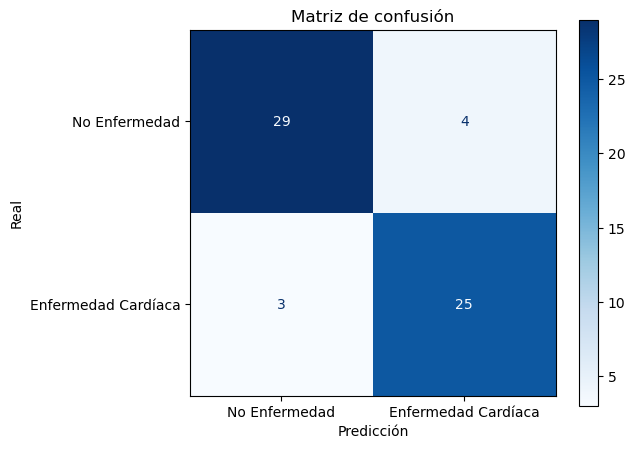

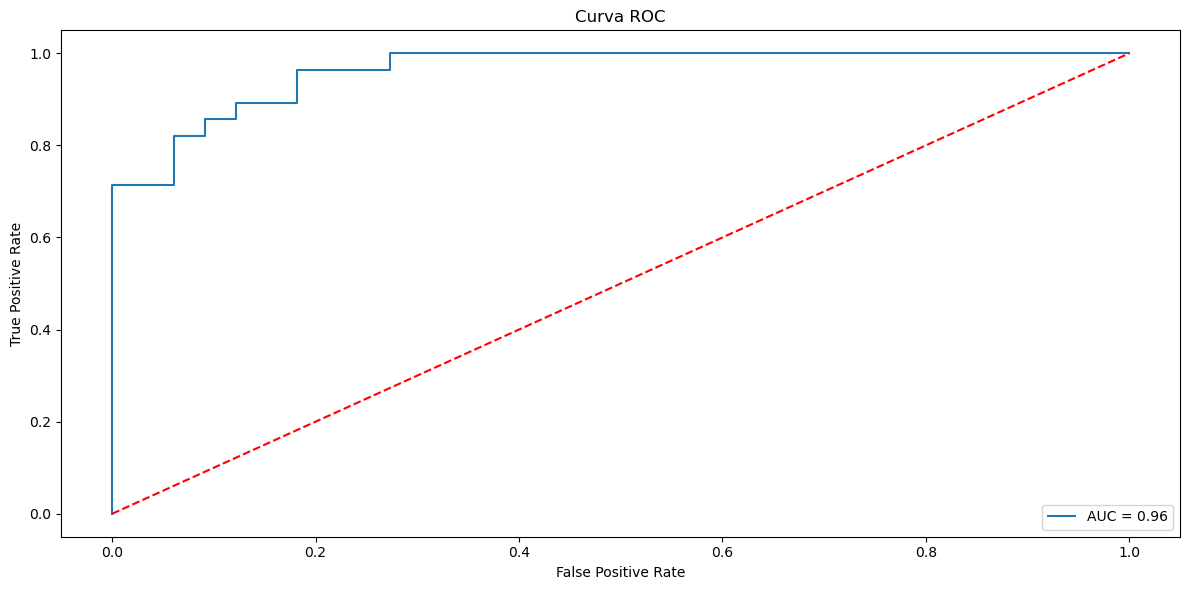

In [47]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_pred = pipeline_logreg_cv.predict(X_test)
y_pred_proba = pipeline_logreg_cv.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Evaluación Logistic Regression")
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1-score:", f1)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                             display_labels=['No Enfermedad', 'Enfermedad Cardíaca'])
disp.plot(cmap='Blues')
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión")
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(12, 6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Interpretación**

1. `Accuracy (88.5%)`:
    - **Interpretación:** El modelo clasifica correctamente el **88.5%** de todas las instancias.
    - **Evaluación:** **Excelente** - Comparable con los modelos Bayesianos.

2. `Recall (89.3%)`:
    - **Interpretación:** El modelo identifica correctamente el **89.3%** de todos los casos **reales de enfermedad cardíaca**.
    - **Evaluación:** **Excelente** sensibilidad. Captura casi todos los pacientes enfermos.
    - **Implicación clínica:** Muy pocos falsos negativos - crucial para aplicaciones médicas.

3. `Precision (86.2%)`:
    - **Interpretación:** El **86.2%** de las predicciones como "enfermo" son correctas.
    - **Evaluación:** **Muy alta** - Pocos falsos positivos.
    - **Implicación clínica:** Minimiza diagnósticos innecesarios y costos asociados.

`4. F1-score (87.7%)`:
    - **Interpretación:** Balance excelente entre Precision y Recall.
    - **Evaluación:** **Excelente** - Indica un modelo bien equilibrado.

### **Análisis de Calibración y Distribución de Probabilidades del Modelo LogisticRegression**

Para evaluar la confiabilidad de las predicciones probabilísticas del modelo LogisticRegression, se generaron dos visualizaciones críticas: un histograma de distribución de probabilidades y una curva de calibración. El histograma permite comparar la densidad de las probabilidades predichas para cada clase real, revelando si el modelo distingue efectivamente entre pacientes sanos y enfermos. La curva de calibración evalúa cómo se alinean las probabilidades predichas con las frecuencias observadas empíricamente, indicando si las probabilidades son confiables para la toma de decisiones clínicas (ej: si una probabilidad predicha del 80% corresponde efectivamente a un 80% de casos reales de enfermedad).

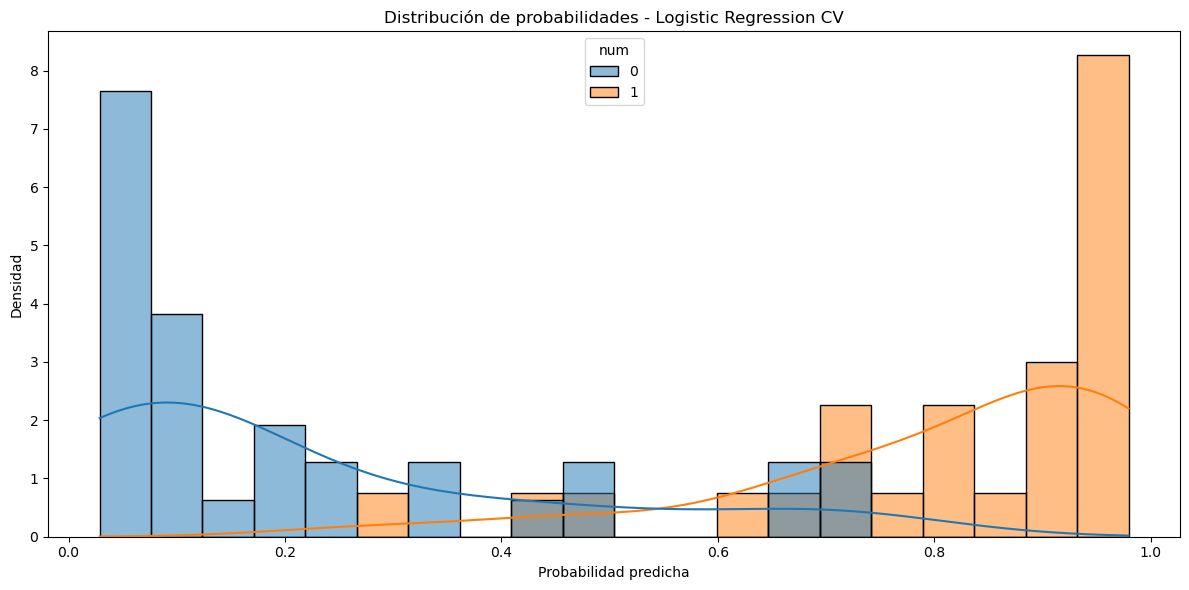

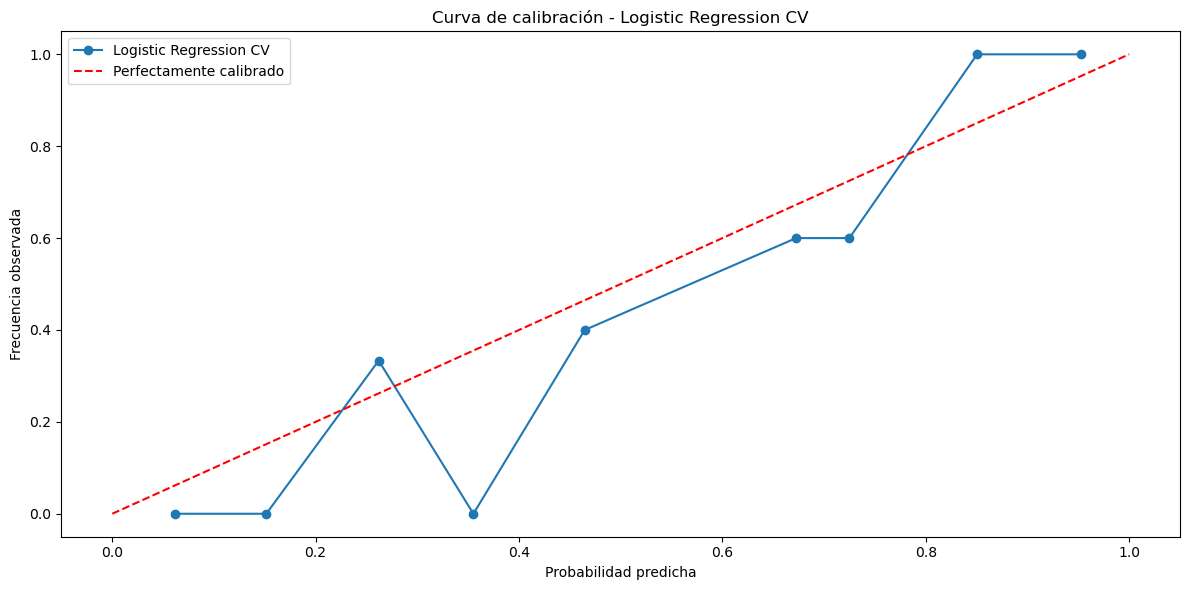

In [48]:
# Histograma de probabilidades
plt.figure(figsize=(12,6))
sns.histplot(x=y_pred_proba, hue=y_test, bins=20, kde=True, stat="density", common_norm=False)
plt.title("Distribución de probabilidades - Logistic Regression CV")
plt.xlabel("Probabilidad predicha")
plt.ylabel("Densidad")
plt.tight_layout()
plt.show()

# Curva de calibración
prob_true, prob_pred = calibration_curve(y_test, y_pred_proba, n_bins=10)

plt.figure(figsize=(12,6))
plt.plot(prob_pred, prob_true, marker='o', label="Logistic Regression CV")
plt.plot([0,1],[0,1],"r--", label="Perfectamente calibrado")
plt.title("Curva de calibración - Logistic Regression CV")
plt.xlabel("Probabilidad predicha")
plt.ylabel("Frecuencia observada")
plt.legend()
plt.tight_layout()
plt.show()


## **Comparación de Modelos**
| Modelo | Accuracy | Precision | Recall | F1-score |
|--------|----------|-----------|--------|----------|
| Logistic Regression | 88.5% | 86.2% | 89.3% | 87.7% |
| BernoulliNB | 91.8% | 89.7% | 92.9% | 91.2% |
| MultinomialNB | 85.2% | 82.8% | 85.7% | 84.2% |
| GaussianNB | 63.9% | 56.8% | 89.3% | 69.4% |